**MSc in Computational Physics Auth**<br>
**Computational Mathematics I**<br>
**Academic Year: 2023-2024**<br>
**Semester 1**<br>
**Ioannis Stergakis**

# **Project 1: 'Solving the equation exp(x) + x - 2 = 0'**

## **Prologue**

In this notebook, we present our code in an attempt to find the solution (if there is one) of the equation $exp(x)+x-2=0$. This equation can not be solved using analytical techniques and formulas, such as the discriminant for a second degree polynomial. Thus, four different numerical methods will be used. Specifically, we will compare three bracketing methods, the **Bisection Method**, the **Standard** and the **Modified False-Position Methods**, and one open-point method, the **Fixed-Point Iteration**, in terms of speed of convergence and ease of use. We will describe each method and we develop the Python algorithm that leads to the approximate solution of the requested equation, along with the errors that follow the approximation. We will illustrate the errors evolution during the implentation of our code, in order to visualize the convergence towards the root. The root is to be estimated to at least six correct significant figures.   

## **1. Theoretical background**

###  **1.1 The Bisection Method**

One way of solving an equation of a variable x, is to bring it into the form $f(x)=0$ and look for the roots of the function $f$, using numerical techniques. The simplest, yet robust numerical technique for finding the roots of a real-valued function $f$, is the Bisection method. As a bracketing method, requires two initial guesses $x_l$ and $x_u$ of the root, the choice of which is essential, as not only the true root must be located between them, but the function $f$ should also be continuous and should change sign $(f(x_l)*f(x_u)<0)$, within the selected interval $[x_l,x_u]$. Given the initial points, we then calculate the midpoint $x_r$ with the formula: $$x_r=\frac{x_l+x_u}{2}$$ 
The check of the sign of the product $f(x_r)*f(x_l)$ comes next. We can distinguish three cases: 
1. $f(x_r)*f(x_l)=0$, which implies that $x_r$ is the true root of f (the iterative process then stops), 
2. $f(x_r)*f(x_l)<0$, which implies that the true root lies within the interval $[x_l,x_r]$, so we set $x_u=x_r$
3. $f(x_r)*f(x_l)>0$, which implies that the true root lies within the interval $[x_r,x_u]$, so we set $x_l=x_r$.

Thus, the initial interval of estimation is updated by division in half. The new approximation of the root, is (again) derived from the formula $x_r=\frac{x_l+x_u}{2}$. The aformentioned process (check and update) is repeated, with the interval $[x_l, x_u]$ getting increasingly narrow (divided in half) by each iteration.

The convergence towards the root stops, when a certain level of accuracy is reached. Τhis level is determined by the number of correct significant figures (digits), we wish our estimate to have. According to Scarborough formula, for $n$ correct significant figures in our approximation, we are provided by the following threshold: $$\epsilon_s=(0.5*10^{2-n})\%$$ 
In each iteration, we calculate the approximate percentage relative error $\epsilon_a$, using the formula: $$\epsilon_a=\left|\frac{x^{new}_r-x^{old}_r}{x^{new}_r}\right|*100\%$$
where $x^{new}$ the approximated root of the current iteration and $x^{old}$ the approximated root of the previous iteration, and then we compare it with the threshold $\epsilon_s$. If the criterion $|\epsilon_a|<\epsilon_s$ is met, the iterative process stops and we can be confident about our result having at least $n$ correct significant figures. 

However, one could accidently ask for a large number of correct significant figures, leading the code to perform an equally heavy and time-consuming computational processing. To prevent this from happening, we define a second convergence criterion by setting a maximum number of iterations to be executed, during the implementation of the convergence code.

###  **1.2 The False-Position Method (Regula Falsi)**

####  1.2.1 The Standard False-Position Method

In addition to the Bisection method, a second bracketing method, the Standard False-Position method, can be used to approximate the roots of a real-valued function $f$. For this method, two initial estimates of the root are required too, satisfying the condition $f(x_l)*f(x_u)<0$. The approximate root, however, does not arise from the formula of the midpoint $x_r=\frac{x_l+x_u}{2}$. That's because, the behaviour of the function in the selected interval $[x_l,x_u]$, is also taken into acount now. For example, $f(x_u)$ could be closer to zero than $f(x_l)$, implying the root is closer to $x_u$ than to $x_l$. 

So, we consider that $f$ follows the behaviour of the line passing through the points $[x_l,f(x_l)]$ and $[x_u,f(x_u)]$ (that's why this method is also known as linear interpolation). The intersection of the line with the x-axis is the approximation of the root and is given by the formula: $$x_r=x_u-\frac{f(x_u)(x_l-x_u)}{f(x_l)-f(x_u)}$$

The check of the sign of the product $f(x_r)*f(x_l)$ comes next, once again, and we distinguish the same three cases, as in the Bisection method: 
1. $f(x_r)*f(x_l)=0$, which implies that $x_r$ is the true root of f (the iterative process then stops), 
2. $f(x_r)*f(x_l)<0$, which implies that the true root lies within the interval $[x_l,x_r]$, so we set $x_u=x_r$
3. $f(x_r)*f(x_l)>0$, which implies that the true root lies within the interval $[x_r,x_u]$, so we set $x_l=x_r$,

followed by the new approximation $x_r$, at the beginning of the next iteration. Τhis way, the estimation interval shortens again by each iteration, but we anticipate faster convergence compared to bisection, due to the inclusion of the form of $f$ during the approximation. The same convergence criteria of Bisection apply here. That is, the iterative process will be terminated, if $|\epsilon_a|<\epsilon_s$ (depending on the correct significant figures requested) or if the maximum number of iterations has been reached.  

####  1.2.2 The Modified False-Position Method

The most common pitfall of the Standard False-Position method is the "one-sided" approach, which could lead to slow convergence, especially when the function has a high degree of curvature. Indeed, it is possible that one of the two bounds of the interval $[x_l,x_u]$ may remain unchanged, as the iterations progress. Τo avoid stagnation of a boundary, we can halve the value of the function at the 'stuck' boundary. This modification shall be applied in the sign checking phase of the product $f(x_r)*f(x_l)$, by adding an extra step to the test process. We have the following cases: 

1. $f(x_r)*f(x_l)=0$, which implies that $x_r$ is the true root of f (the iterative process then stops), 
2. $f(x_r)*f(x_l)<0$, which implies that the true root lies within the interval $[x_l,x_r]$, so we set $x_u=x_r$. Additionally, if the product is found negative for two or more times in a row (meaning the lower bound $x_l$ is stagnant), we set $f(x_l)=\frac{f(x_l)}{2}$,
3. $f(x_r)*f(x_l)>0$, which implies that the true root lies within the interval $[x_r,x_u]$, so we set $x_l=x_r$. Additionally, if the product is found positive for two or more times in a row (meaning the upper bound $x_u$ is stagnant), we set $f(x_u)=\frac{f(x_u)}{2}$.

As a result, the code is accelerated and the root is approximated from both sides, leading to faster convergence. This is the Modified False-Position method.

###  **1.3 The Fixed-Point Iteration**

The fixed point of a one-variable function $g(x)$, is a value c of its independent variable $x$, such that $g(c)=c$, i.e the value c remains unchanged when the function is applied. Geometrically, the fixed point (or points) of a function $g$ are the x-axis components of the intersections of the $y=g(x)$ curve with the $y=x$ curve. 

We can use this property of functions to calculate the roots of equations numerically. All we have to do is bring the equation into the form $x=g(x)$. The fixed points of $g$, are the roots of the equation. Thus, starting from an initial point $x_o$, we calculate the value $g(x_o)$. If $x_o\neq g(x_o)$ we update the guess assigning to it the value $g(x_o)$. We repeat this process, using the formula: $$x_{i+1}=g(x_i)$$
until we find a value $x_r$, such that $x_r=g(x_r)$ or until one of our convergence criteria is met. We apply the same convergence criteria, as in the afformentioned bracketing methods (that is, $|\epsilon_a|<\epsilon_s$ and maximum number of iterations reached). Only that now, we have one initial guess instead of two, making the Fixed-Point iteration an open-point method. So, the approximate percent relative error $e_a$ of each iteration, is calculated by the formula:
$$\epsilon_a=\left|\frac{x_{i+1}-x_i}{x_{i+1}}\right|*100\%$$

The selection of the $g$ function is also important, as the wrong choice of function will lead to a devergence from the true root. More specifically, the first derivative of the function must satisfy the relation: $$|g^{'}(x)|<1$$ 
in our region of interest, for the Fixed-Point iteration to converge. 

## **2. Code development**

In this chapter we develop our code to execute the four numerical methods discussed in the previous chapter. All of the code is in the form of Python functions, as they were created with the *def* and *return* command. After each function, a description of its operation is included. 

Before we start our code development, we have to import the necessary ***Python*** modules. For numerical operations and results and creation of arrays, we import the ***NumPy*** module. For symbolic operations and results, we import the ***SymPy*** module. For plotting, we import the ***Matplotlib.pyplot*** module, as it is shown below:

In [3]:
import numpy as np
import sympy as smp
import matplotlib.pyplot as plt

###  **2.1 Determination of the initial points**

In [25]:
def ftransf(string):
    string = string.lower() # convert all characters of the given string to lowercase
    string = string.replace('y','x') # replace every 'y' character with 'x'
    string = string.replace('z','x') # replace every 'y' character with 'x'
    return string

<u>Description of **ftransf** function</u>:

**Input**<br>
Every string character

**Main Body**<br>
The *string.lower()* command is used to convert all characters of the given string to lowercase<br>
The *string.replace('y','x')* command is used to replace every 'y' character of the given string with 'x'<br>
The *string.replace('z','x')* command is used to replace every 'z' character of the given string with 'x'<br>
After every transforrmation the converted string is reassigned to the variable string

**Return**<br>
The converted string input

<u>*Notes*:<u><br>
    
During the operation of some of the following functions, the user is asked to type the formula of $f$ or $g$ one-variable functions. However, one could accidentally type two variables or use uppercase characters. The **ftransf** function fixes this making sure that the used formula includes the x variable only. For example, a typed formula 'NP.EXP(Y)+X-2' would be converted to 'np.exp(x)+x-2'.   

In [27]:
def Graphfunc():
    # Selection of the graph purpose
    u = int(input('Choose the use of the graph (1=BM,2=FPI,3=FPI Derivative):'))
    while u!=1 and u!=2 and u!=3:
        u = int(input('Choose the use of the graph (1=BM,2=OM,3=Derivative)'))
    h_formula = input('Type your one variable function formula:')
    xmin = float(input('Give the lower limit of the x-axis of the plot:'))
    xmax = float(input('Give the upper limit of the x-axis of the plot:'))
    h_formula = ftransf(h_formula)
    def func(x):
        return eval(h_formula)
    
    # Plotting the selected graph
    x=np.linspace(xmin,xmax,200)
    fig, ax = plt.subplots(figsize=(8,5))
    if u==1:
        zer = np.zeros(200)
        plt.plot(x,func(x),lw=2,color='cornflowerblue',label='y = f(x) = %s'%h_formula)
        plt.plot(x,zer,'--',lw=1.7,color='black',label='y = 0')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Search for possible roots of the function f(x) in [%.2f,%.2f]'%(xmin,xmax))
        plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
        plt.grid()
        plt.show()
    elif u==2:
        plt.plot(x,func(x),lw=2,color='cornflowerblue',label='y = g(x) = %s'%h_formula)
        plt.plot(x,x,'--',lw=1.7,color='black',label='y = x')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Investigating the behaviour of the function g(x) in [%.2f,%.2f]'%(xmin,xmax))
        plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
        plt.grid()
        plt.show()
    elif u==3:
        oneval = np.ones(200)
        plt.plot(x,func(x),lw=2,color='cornflowerblue',label='y = dg(x) = %s'%h_formula)
        plt.plot(x,oneval,'--',lw=1.7,color='black',label='y = 1')
        plt.plot(x,-oneval,'--',lw=1.7,color='black',label='y = -1')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Investigating the criteria |dg(x)|<=1 in [%.2f,%.2f]'%(xmin,xmax))
        plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
        plt.grid()
        plt.show()

<u>Description of **Graphfunc** function</u>:

**Input**<br>
No input is included. All the inputs are given through the operation of the main body

**Main Body**<br>
a. Selection of the graph purpose section:<br>
In this section the user is asked to choose the purpose of the graph to be made, by typing the appropriate number. For plotting a function to be used for a bracketing method (BM) the user must type 1, for plotting a function to be used for Fixed-Point iteration (FPI) the user must type 2 and for plotting the derivative of a function to be used for Fixed-Point iteration (FPI Derivative) the user must type 3. The typing of the function formula in string format comes next, along with the bounds of the graph. Then the formula is fixed by using the function **ftransf** and a temporary function (**func**) of x is defined, utilizing the fixed given formula. Thε utilization is achievable by using the command *eval*('string input'), which calculates the value of given string input.

b. Plotting the selected graph<br>
In this section, the algorithm constructs the corresponding diagram, depending on the purpose chosen by the user. If the user has chosen to use the diagram for a bracketing the algorithm plots the y=func(x) curve alongside with the y=0 curve. If the user has chosen to use the diagram for the function $g$ of Fixed-Point iteration the algorithm plots the y=func(x) curve alongside with the y=x curve. Finally, if the user has chosen to use the diagram for the derivative function $g^{'}$ of Fixed-Point iteration the algorithm plots the y=func(x) curve alongside with the y=-1 and y=1 curve.

**Return**<br>
No return is included

<u>*Notes*:<u><br>

The **Graphfunc** function will be used to investigate the behaviour of the functions $f$ and $g$, of the respective discussed methods. 

### **2.2 Convergence code**

#### 2.2.1 Approximate percent relative error function 

In [31]:
def fe_a(xr_new,xr_old):
    return abs((xr_new-xr_old)/xr_new)*100

<u>Description of **fe_a** function</u>:

**Input**<br>
*xr_new*: the new approximate root<br>
*xr_old*: the old approximate root<br>

**Main Body**<br>
Calculation of the approximate percent relative error $e_a$ using the formula: $$\epsilon_a=\left|\frac{x^{new}_r-x^{old}_r}{x^{new}_r}\right|*100\%$$

**Return**<br>
*e_a*: the calculated approximate percent relative error $e_a$

<u>*Notes*:<u><br>
    
The **fe_a** function will be used to calculate the approximate percent relative error $e_a$ of each iteration.

#### 2.2.2 Bisection Method

In [33]:
def fbisec(func,x_l,x_u,n,imax):
    # setting the necessary constants and storage lists
    ival = [] # number of iterations
    solval = [] # approximate values x_r of the root
    lbound = [] # lower bound x_l values
    ubound = [] # upper bound x_u values
    e_aval = [] # approximate percent relative error values
    signval = [] # sign of the f(x_r)*f(x_l) product
    e_s = 0.5*10**(2-n) # tolerated error for n significnat figures according to Scarborough formula
    trueroot = 0 # checks if the true root is found
    
    # implementing the iterative method
    i=0
    f_l = func(x_l) # calculating the f value at the initial lower bound x_L
    f_u = func(x_u) # calculating the f value at the initial upper bound x_u 
    e_a='NaN'
    while (e_a=='NaN' or e_a>=e_s) and i<imax:
        x_r = (x_l+x_u)/2 # iterative sequence of the bisection method
        f_r = func(x_r) # calculating the f value at the new approximation x_r
        ival.append(i+1)
        solval.append(x_r)
        lbound.append(x_l)
        ubound.append(x_u)
        if i==0 or x_r==0:
            e_a='NaN' # lack of approximate errors in the first iteration or x_r=0
            e_aval.append(e_a)
        else:
            e_a = fe_a(x_r,solval[i-1]) # approximate percent relative error of the current iteration
            e_aval.append(e_a)
        if f_r*f_l<0:
            sign = '-'
            signval.append(sign)
            x_u = x_r
            f_u = func(x_u) # recalculating the f value at the changed upper bound x_u
        elif f_r*f_l>0:
            sign = '+'
            signval.append(sign)
            x_l = x_r
            f_l = func(x_l) # recalculating the f value at the changed lower bound x_L
        elif f_r==0:
            sign = 'o'
            signval.append(sign)
            trueroot = 1
            break
        i = i + 1 # increasing the iteration index by 1    
    return [e_s,ival,solval,lbound,ubound,e_aval,signval,trueroot]

<u>Description of **fbisec** function</u>:

**Input**<br>
*func*: the selected $f$ function that is used for the Bisection method<br>
*x_l*: the initial lower bound guess<br>
*x_u*: the initial upper bound guess<br>
*n*: the number of the correct significant figures we wish our approximation to have<br>
*imax*: the maximum number of iterations to be executed<br>

**Main Body**<br>
a. Setting the necessary constants and storage lists<br>
In this section the algorithm creates the lists to be filled with the approximation information. These include a list for the number of iterations $i$ (*ival*), a list for the approximate roots values $x_r$ (*solval*), a list for the lower bound values $x_l$ during the approximation (*lbound*), a list for the upper bound values $x_u$ during the approximation (*ubound*), a list for the approximate percent relative error values $e_a$ (*e_aval*) and a list for the sign of the $f(x_r)*f(x_l)$ product (*signval*). Additionally, the algorithm assigns to the variable *e_s* the threshold provided by the Scarborough formula for the selected number of the correct significant figures: $$\epsilon_s=(0.5*10^{2-n})\%$$ and assigns the value 0 to the variable *trueroot* that checks if the true root is found.

b. Implementing the Bisection iterative method<br>
We start the iterative process by assigning the value 0 to the variable *i* of the iterations and the 'NaN' word to the *e_a* variable of the approximate errors, as no approximate errors can be calculated can be calculated in the first iteration. We also calculate the selected $f$ function values at the initial lower and upper bound, and we assign these values to the *f_l* and *f_u* variables, respectively. We use the *while* command to implement the iterative process. We use the *while* command to implement the iterative process. The while loop will 'run', until the Scarborough criteria is met ($|\epsilon_a|<\epsilon_s$) or until the maximum number of iterations is reached.

At each iteration the new root approximation $x_r$ is calculated using the Bisection formula: $$x_r=\frac{x_l+x_u}{2}$$
The selected function $f$ value at $x_r$ is also calculated. Then, the algorithm calculates the approximate percent relative error of the current iteration, by using the **fe_a** function. Of course, $e_a$ would be undefined if we are in the the first iteration (i=0) or if the approximate value happens to be equal to 0 ($x_r=0$). In this case, the code assigns the 'NaN' word to the *e_a* variable.

The check phase of the $f(x_r)*f(x_l)$ product, comes next. We implement this phase, by creating an *if* control flow 'tree', according to the three cases of the Bisection method:
 
1. $f(x_r)*f(x_l)<0$, which implies that the true root lies within the interval $[x_l,x_r]$, so we set $x_u=x_r$ and assign the '-' symbol to the *sign* variable. We also recalculate the *f_u* value at the changed upper bound.
2. $f(x_r)*f(x_l)>0$, which implies that the true root lies within the interval $[x_r,x_u]$, so we set $x_l=x_r$ and assign the '+' symbol to the *sign* variable. We also recalculate the *f_l* value at the changed lower bound.
3. $f(x_r)*f(x_l)=0$, which implies that $x_r$ is the true root of f. The 'o' symbol is assigned to the *sign* variable, the value 1 is assigned to the *trueroot* variable and the iterative process is being terminated using the *break* command.

Finally, the value of the iteration index *i* is increased by 1, moving on to the next iteration. During each iteration the values of the variables *i*, *x_r*, *x_l*, *x_u*, *e_a* and *sign* are appended to the respective lists.

**Return**<br>
*[e_s,ival,solval,lbound,ubound,e_aval,signval,trueroot]*: a nested list containing all the information of the executed approximation

<u>*Notes*:<u><br>
    
The **fbisec** function implenents the Bisection iterative method and will be used as part of the following **Convresults**, **Gconverrors** and **Compall** functions

#### 2.2.3 Standard False-Position Method (Linear Interpolation)

In [35]:
def ffalseP(func,x_l,x_u,n,imax):
    # setting the necessary constants and storage lists
    ival = [] # number of iterations
    solval = [] # approximate values x_r of the root
    lbound = [] # lower bound x_l values
    ubound = [] # upper bound x_u values
    e_aval = [] # approximate errors values
    signval = [] # sign of the f(x_r)*f(x_l) product
    e_s = 0.5*10**(2-n) # tolerated error for n significnat figures according to Scarborough formula
    trueroot = 0 # checks if the true root is found
    
    # starting the iterative method
    i=0
    f_l = func(x_l) # calculating the f value at the initial lower bound x_L
    f_u = func(x_u) # calculating the f value at the initial upper bound x_u
    e_a='NaN'
    while (e_a=='NaN' or e_a>=e_s) and i<imax:
        x_r = x_u - (f_u*(x_l-x_u))/(f_l-f_u) # iterative sequence of the false-position method
        f_r = func(x_r) # calculating the f value at the new approximation x_r
        ival.append(i+1)
        solval.append(x_r)
        lbound.append(x_l)
        ubound.append(x_u)
        if i==0 or x_r==0:
            e_a='NaN' # lack of approximate errors in the first iteration or x_r=0
            e_aval.append(e_a)
        else:
            e_a = fe_a(x_r,solval[i-1]) # approximate percent relative error of the current iteration
            e_aval.append(e_a)
        if f_r*f_l<0:
            sign = '-'
            signval.append(sign)
            x_u = x_r
            f_u = func(x_u) # recalculating the f value at the changed upper bound x_u
        elif f_r*f_l>0:
            sign = '+'
            signval.append(sign)
            x_l = x_r
            f_l = func(x_l) # recalculating the f value at the changed lower bound x_L
        elif f_r==0:
            sign = 'o'
            signval.append(sign)
            trueroot = 1
            break
        i = i + 1    
    return [e_s,ival,solval,lbound,ubound,e_aval,signval,trueroot]

<u>Description of **ffalseP** function</u>:

**Input**<br>
*func*: the selected $f$ function that is used for the Standard False-Position method<br>
*x_l*: the initial lower bound guess<br>
*x_u*: the initial upper bound guess<br>
*n*: the number of the correct significant figures we wish our approximation to have<br>
*imax*: the maximum number of iterations to be executed<br>

**Main Body**<br>
a. Setting the necessary constants and storage lists<br>
In this section the algorithm creates the lists to be filled with the approximation information. These include a list for the number of iterations $i$ (*ival*), a list for the approximate roots values $x_r$ (*solval*), a list for the lower bound values $x_l$ during the approximation (*lbound*), a list for the upper bound values $x_u$ during the approximation (*ubound*), a list for the approximate percent relative error values $e_a$ (*e_aval*) and a list for the sign of the $f(x_r)*f(x_l)$ product (*signval*). Additionally, the algorithm assigns to the variable *e_s* the threshold provided by the Scarborough formula for the selected number of the correct significant figures: $$\epsilon_s=(0.5*10^{2-n})\%$$ and assigns the value 0 to the variable *trueroot* that checks if the true root is found.

b. Implementing the Standard False-Position iterative method<br>
We start the iterative process by assigning the value 0 to the variable *i* of the iterations and the 'NaN' word to the *e_a* variable of the approximate errors, as no approximate errors can be calculated can be calculated in the first iteration. We also calculate the selected $f$ function values at the initial lower and upper bound, and we assign these values to the *f_l* and *f_u* variables, respectively. We use the *while* command to implement the iterative process. The while loop will 'run', until the Scarborough criteria is met ($|\epsilon_a|<\epsilon_s$) or until the maximum number of iterations is reached.

At each iteration the new root approximation $x_r$ is calculated using the False-Position formula: $$x_r=x_u-\frac{f(x_u)(x_l-x_u)}{f(x_l)-f(x_u)}$$
The selected function $f$ value at $x_r$ is also calculated. Then, the algorithm calculates the approximate percent relative error of the current iteration, by using the **fe_a** function. Of course, $e_a$ would be undefined if we are in the the first iteration (i=0) or if the approximate value happens to be equal to 0 ($x_r=0$). In this case, the code assigns the 'NaN' word to the *e_a* variable.

The check phase of the $f(x_r)*f(x_l)$ product, comes next. We implement this phase, by creating an *if* control flow 'tree', according to the three cases of the Standard False-Position method:
 
1. $f(x_r)*f(x_l)<0$, which implies that the true root lies within the interval $[x_l,x_r]$, so we set $x_u=x_r$ and assign the '-' symbol to the *sign* variable. We also recalculate the *f_u* value at the changed upper bound.
2. $f(x_r)*f(x_l)>0$, which implies that the true root lies within the interval $[x_r,x_u]$, so we set $x_l=x_r$ and assign the '+' symbol to the *sign* variable. We also recalculate the *f_l* value at the changed lower bound.
3. $f(x_r)*f(x_l)=0$, which implies that $x_r$ is the true root of f. The 'o' symbol is assigned to the *sign* variable, the value 1 is assigned to the *trueroot* variable and the iterative process is being terminated using the *break* command.

Finally, the value of the iteration index *i* is increased by 1, moving on to the next iteration. During each iteration the values of the variables *i*, *x_r*, *x_l*, *x_u*, *e_a* and *sign* are appended to the respective lists.

**Return**<br>
*[e_s,ival,solval,lbound,ubound,e_aval,signval,trueroot]*: a nested list containing all the information of the executed approximation

<u>*Notes*:<u><br>
    
The **ffalseP** function implenents the Standard False-Position iterative method and will be used as part of the following **Convresults**, **Gconverrors** and **Compall** functions

#### 2.2.4 Modified False-Position Method

In [37]:
def fmodfalseP(func,x_l,x_u,n,imax):
    # setting the necessary constants and storage lists
    ival = [] # number of iterations
    solval = [] # approximate values x_r of the root
    lbound = [] # lower bound x_l values
    ubound = [] # upper bound x_u values
    flbound = [] # function values f(x_l) at lower bound
    fubound = [] # function values f(x_u) at upper bound
    e_aval = [] # approximate errors values
    signval = [] # sign of the f(x_r)*f(x_l) product
    e_s = 0.5*10**(2-n) # tolerated error for n significnat figures according to Scarborough formula
    i_l = 0 # number of consecutive appereances of the negative product f(x_r)*f(x_l)
    i_u = 0 # number of consecutive appereances of the positive product f(x_r)*f(x_l)
    trueroot = 0 # checks if the true root is found
    
    # starting the iterative method
    i=0
    f_l = func(x_l) # calculating the f value at the initial lower bound x_L
    f_u = func(x_u) # calculating the f value at the initial upper bound x_u
    e_a='NaN'
    while (e_a=='NaN' or e_a>=e_s) and i<imax:
        x_r = x_u - (f_u*(x_l-x_u))/(f_l-f_u) # iterative sequence of the false-position method
        f_r = func(x_r) # calculating the f value at the new approximation x_r
        ival.append(i+1)
        solval.append(x_r)
        lbound.append(x_l)
        ubound.append(x_u)
        flbound.append(f_l)
        fubound.append(f_u)
        if i==0 or x_r==0:
            e_a='NaN' # lack of approximate errors in the first iteration or x_r=0
            e_aval.append(e_a)
        else:
            e_a = fe_a(x_r,solval[i-1]) # approximate percent relative error of the current iteration
            e_aval.append(e_a)
        if f_r*f_l<0:
            sign = '-'
            signval.append(sign)
            x_u = x_r
            f_u = func(x_u) # recalculating the f value at the changed upper bound x_u
            i_u = 0 # reseting the number of consecutive appereances of the positive product f(x_r)*f(x_l) to 0
            i_l = i_l + 1 # increasing the number of consecutive appereances of the negative product f(x_r)*f(x_l) by 1
            if i_l>=2:
                f_l=f_l/2
        elif f_r*f_l>0:
            sign = '+'
            signval.append(sign)
            x_l = x_r
            f_l = func(x_l) # recalculating the f value at the changed lower bound x_l
            i_l = 0 # reseting the number of consecutive appereances of the negative product f(x_r)*f(x_l) to 0
            i_u = i_u + 1 # increasing the number of consecutive appereances of the positive product f(x_r)*f(x_l) by 1
            if i_u>=2:
                f_u=f_u/2
        elif f_r==0:
            trueroot = 1
            sign = 'o'
            signval.append(sign)
            break
        i = i + 1    
    return [e_s,ival,solval,lbound,ubound,flbound,fubound,e_aval,signval,trueroot]

<u>Description of **fmodfalseP** function</u>:

**Input**<br>
*func*: the selected $f$ function that is used for the Modified False-Position method<br>
*x_l*: the initial lower bound guess<br>
*x_u*: the initial upper bound guess<br>
*n*: the number of the correct significant figures we wish our approximation to have<br>
*imax*: the maximum number of iterations to be executed<br>

**Main Body**<br>
a. Setting the necessary constants and storage lists<br>
In this section the algorithm creates the lists to be filled with the approximation information. These include a list for the number of iterations $i$ (*ival*), a list for the approximate roots values $x_r$ (*solval*), a list for the lower bound values $x_l$ during the approximation (*lbound*), a list of the selected function $f$ values at the lower bound (*flbound*), a list of the selected function $f$ values at the upper bound (*fubound*), a list for the upper bound values $x_u$ during the approximation (*ubound*), a list for the approximate percent relative error values $e_a$ (*e_aval*) and a list for the sign of the $f(x_r)*f(x_l)$ product (*signval*). Additionally, the algorithm assigns to the variable *e_s* the threshold provided by the Scarborough formula for the selected number of the correct significant figures: $$\epsilon_s=(0.5*10^{2-n})\%$$ and assigns the value 0 to the variable *trueroot* that checks if the true root is found. The value 0 is assigned to the *i_l* and *i_u* variables, that count the consecutive times of the product $f(x_r)*f(x_l)$ being negative or positive, respectively.

b. Implementing the Modified False-Position iterative method<br>
We start the iterative process by assigning the value 0 to the variable *i* of the iterations and the 'NaN' word to the *e_a* variable of the approximate errors, as no approximate errors can be calculated can be calculated in the first iteration. We also calculate the selected $f$ function values at the initial lower and upper bound, and we assign these values to the *f_l* and *f_u* variables, respectively. We use the *while* command to implement the iterative process. The while loop will 'run', until the Scarborough criteria is met ($|\epsilon_a|<\epsilon_s$) or until the maximum number of iterations is reached.

At each iteration the new root approximation $x_r$ is calculated using the False-Position formula: $$x_r=x_u-\frac{f(x_u)(x_l-x_u)}{f(x_l)-f(x_u)}$$
The selected function $f$ value at $x_r$ is also calculated. Then, the algorithm calculates the approximate percent relative error of the current iteration, by using the **fe_a** function. Of course, $e_a$ would be undefined if we are in the the first iteration (i=0) or if the approximate value happens to be equal to 0 ($x_r=0$). In this case, the code assigns the 'NaN' word to the *e_a* variable.

The check phase of the $f(x_r)*f(x_l)$ product, comes next. We implement this phase, by creating an *if* control flow 'tree', according to the three cases of the Standard False-Position method:
 
1. $f(x_r)*f(x_l)<0$, which implies that the true root lies within the interval $[x_l,x_r]$, so we set $x_u=x_r$ and assign the '-' symbol to the *sign* variable. We also recalculate the *f_u* value at the changed upper bound. We reset the number of consecutive appereances of the positive product $f(x_r)*f(x_l)$ to 0 and increase the number of consecutive appereances of the negative product $f(x_r)*f(x_l)$ by 1. Additionally, if the product is found negative for two or more times in a row (*i_l>=2*), we set $f_l=\frac{f_l}{2}$.
2. $f(x_r)*f(x_l)>0$, which implies that the true root lies within the interval $[x_r,x_u]$, so we set $x_l=x_r$ and assign the '+' symbol to the *sign* variable. We also recalculate the *f_l* value at the changed lower bound. We reset the number of consecutive appereances of the negative product $f(x_r)*f(x_l)$ to 0 and increase the number of consecutive appereances of the positive product $f(x_r)*f(x_l)$ by 1. Additionally, if the product is found positive for two or more times in a row (*i_u>=2*), we set $f_u=\frac{f_u}{2}$
3. $f(x_r)*f(x_l)=0$, which implies that $x_r$ is the true root of f. The 'o' symbol is assigned to the *sign* variable, the value 1 is assigned to the *trueroot* variable and the iterative process is being terminated using the *break* command.

Finally, the value of the iteration index *i* is increased by 1, moving on to the next iteration. During each iteration the values of the variables *i*, *x_r*, *x_l*, *x_u*, *f_l*, *f_u*, *e_a* and *sign* are appended to the respective lists.

**Return**<br>
*[e_s,ival,solval,lbound,ubound,flbound,fubound,e_aval,signval,trueroot]*: a nested list containing all the information of the executed approximation

<u>*Notes*:<u><br>
    
The **fmodfalseP** function implenents the Modified False-Position iterative method and will be used as part of the following **Convresults**, **Gconverrors** and **Compall** functions

#### 2.2.5 Fixed-Point Iteration

In [39]:
def ffixedP(func,x_o,n,imax):
    # setting the necessary constants and storage lists
    ival = [] # number of iterations
    solval = [] # approximate values x_r of the root
    gval = [] # g(x_r) values 
    e_aval = [] # approximate errors values
    e_s = 0.5*10**(2-n) # tolerated error for n significnat figures according to Scarborough formula
    trueroot = 0 # checks if the true root is found
    
    # starting the iterative method
    i = 0 # indexing the 'zero' iteration 
    x_r = x_o # appending the initial guess value to the variable x_r of approximate values of the root
    e_a = 'NaN' # lack of approximate error in this iteration
    g_r = func(x_r) # g(x) value at x_r
    ival.append(i)
    solval.append(x_r)
    gval.append(g_r)
    e_aval.append(e_a)    
    while (e_a=='NaN' or e_a>=e_s) and i<imax:
        i = i + 1
        x_r = func(x_r) # iterative sequence of the fixed-point iteration
        g_r = func(x_r) # g(x) value at x_r
        if x_r==0:
            e_a='NaN' # infinite denominator of the approximate percent relative error
            e_aval.append(e_a)
        else:
            e_a = fe_a(x_r,solval[i-1]) # approximate percent relative error of the current iteration
            e_aval.append(e_a)
        ival.append(i)
        solval.append(x_r)
        gval.append(g_r)
        if x_r==solval[i-1]:
            trueroot = 1
            break
    return [e_s,ival,solval,gval,e_aval]

<u>Description of **ffixedP** function</u>:

**Input**<br>
*func*: the selected $g$ function that is used for the Fixed-Point Iteration<br>
*x_o*: the initial guess<br>
*n*: the number of the correct significant figures we wish our approximation to have<br>
*imax*: the maximum number of iterations to be executed<br>

**Main Body**<br>
a. Setting the necessary constants and storage lists<br>
In this section the algorithm creates the lists to be filled with the approximation information. These include a list for the number of iterations $i$ (*ival*), a list for the approximate roots values $x_r$ (*solval*), a list for the selected $g$ function values at $x_r$ (*gval*) and a list for the approximate percent relative error values $e_a$ (*e_aval*). Additionally, the algorithm assigns to the variable *e_s* the threshold provided by the Scarborough formula for the selected number of the correct significant figures: $$\epsilon_s=(0.5*10^{2-n})\%$$ and assigns the value 0 to the variable *trueroot* that checks if the true root is found.

b. Implementing the Fixed-Point Iteration<br>
We start the iterative process by assigning the value 0 to the variable *i* of the iterations and the 'NaN' word to the *e_a* variable of the approximate errors, as no approximate errors can be calculated can be calculated at the beginning of the iterative proges. We also append the initial guess value to the variable x_r of approximate values of the root and calculate the $g$ function value at $x_r$. We use the *while* command to implement the iterative process. The while loop will 'run', until the Scarborough criteria is met ($|\epsilon_a|<\epsilon_s$) or until the maximum number of iterations is reached.

At the start of each iteration the iteration index *i* is increased by 1 and the new root approximation $x_r$ is calculated using the Fixed-Point Iteration formula: $$x^{new}_r=g(x^{old}_r)$$
The selected function $g$ value at $x_r$ is also calculated. Then, the algorithm calculates the approximate percent relative error of the current iteration, by using the **fe_a** function. Of course, $e_a$ would be undefined if we are in the the first iteration (i=0) or if the approximate value happens to be equal to 0 ($x_r=0$). In this case, the code assigns the 'NaN' word to the *e_a* variable.

Finally, the true root is made. If the current approximation ($x^{new}_r$) is equall to the $g$ value of the previous approximation ($g(x^{old}_r)$), the algorithm assigns the value 1 to the *trueroot* variable and terminates the *while 'loop'* using the *break* command.

During each iteration the values of the variables *i*, *x_r*, *g_r* and *e_a* are appended to the respective lists.

**Return**<br>
*[e_s,ival,solval,gval,e_aval]*: a nested list containing all the information of the executed approximation

<u>*Notes*:<u><br>
    
The **ffixedP** function implenents the Fixed-Point Iteration iterative method and will be used as part of the following **Convresults**, **Gconverrors** and **Compall** functions

### **2.3 Display of convergence results**

The following **Convresults** function is used to display the results of the convergence methods. The user of this function should choose its preferable method, by typing the respective number (1 for Bisection, 2 for Standard False-Position, 3 for Modified False-Position and 4 for Fixed-Point Iteration) and the respective function ($f$ or $g$) formula. He should also type the initial guesses, as well as the number of the correct significant figures ($n$) we wishes its approximation to have. Then the algorithm fixes the typed formula and prints the selected convergence method results in a table form. (A maximum number of 100 iterations is applied, by setting *imax*=100).

In [41]:
def Convresults():
    # selection of the method
    method = int(input('Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI):'))
    while method!=1 and method!=2 and method!=3 and method!=4:
        method = int(input('Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI)'))
    if method < 4:
        f_formula = input('Type the f(x) formula:')
        x_l = float(input('Give the initial lower bound of the approximation xl:'))
        x_u = float(input('Give the initial upper bound of the approximation xu:'))
        n = int(input('Give the number of the correct significant figures:'))
        print('')
        f_formula = ftransf(f_formula)
        def func(x):
            return eval(f_formula)

    else:
        g_formula = input('Type the g(x) formula:')
        x_o = float(input('Give the initial guess xo:'))
        n = int(input('Give the number of the correct significant figures:'))
        print('')
        g_formula = ftransf(g_formula)
        def func(x):
            return eval(g_formula)
     
    # presenting the results
    if method==1:
        e_s = fbisec(func,x_l,x_u,n,100)[0]
        ival = fbisec(func,x_l,x_u,n,100)[1]
        solval = fbisec(func,x_l,x_u,n,100)[2]
        lbound = fbisec(func,x_l,x_u,n,100)[3]
        ubound = fbisec(func,x_l,x_u,n,100)[4]
        e_aval = fbisec(func,x_l,x_u,n,100)[5]
        signval = fbisec(func,x_l,x_u,n,100)[6]
        trueroot = fbisec(func,x_l,x_u,n,100)[7]
        print('The Bisection method was used for the function: f(x) = %s'%f_formula)
        print('Tolerance according to Scarborough formula: e_s = %.6f %%'%e_s)
        print('-----------------------------------------------------------------------')
        print('i       x_r              x_l             x_u          e_a (%)')
        print('-----------------------------------------------------------------------')
        m=len(ival)
        for i in range(0,m):
            if type(e_aval[i])==str:
                print('%d   %.10f    %.10f    %.10f    %s    (%s)'%(ival[i],solval[i],lbound[i],ubound[i],e_aval[i],signval[i]))
            else:
                print('%d   %.10f    %.10f    %.10f    %.6f    (%s)'%(ival[i],solval[i],lbound[i],ubound[i],e_aval[i],signval[i]))
        print('-----------------------------------------------------------------------')
        if trueroot == 1:
            print('The true root is found equal to: %.10f after %d iterations'%(solval[m-1],ival[m-1]))
        elif m == 100:
            print('Max number of 100 iterations has been reached')    
        else:    
            print('The approximation has been completed after %d iterations'%ival[m-1])
            print('The approximated root is equal to: %.10f  (%d correct significant figures)'%(solval[m-1],n))
        
    elif method==2:
        e_s = ffalseP(func,x_l,x_u,n,100)[0]
        ival = ffalseP(func,x_l,x_u,n,100)[1]
        solval = ffalseP(func,x_l,x_u,n,100)[2]
        lbound = ffalseP(func,x_l,x_u,n,100)[3]
        ubound = ffalseP(func,x_l,x_u,n,100)[4]
        e_aval = ffalseP(func,x_l,x_u,n,100)[5]
        signval = ffalseP(func,x_l,x_u,n,100)[6]
        trueroot = ffalseP(func,x_l,x_u,n,100)[7]
        print('The Standard False-Position method was used for the function: f(x) = %s'%f_formula)
        print('Tolerance according to Scarborough formula: e_s = %.6f %%'%e_s)
        print('-----------------------------------------------------------------------')
        print('i       x_r            x_l              x_u           e_a (%)')
        print('-----------------------------------------------------------------------')
        m=len(ival)
        for i in range(0,m):
            if type(e_aval[i])==str:
                print('%d   %.10f    %.10f    %.10f    %s    (%s)'%(ival[i],solval[i],lbound[i],ubound[i],e_aval[i],signval[i]))
            else:
                print('%d   %.10f    %.10f    %.10f    %.6f    (%s)'%(ival[i],solval[i],lbound[i],ubound[i],e_aval[i],signval[i]))
        print('-----------------------------------------------------------------------')
        if trueroot == 1:
            print('The true root is found equal to: %.10f after %d iterations'%(solval[m-1],ival[m-1]))
        elif m == 100:
            print('Max number of 100 iterations has been reached')    
        else:    
            print('The approximation has been completed after %d iterations'%ival[m-1])
            print('The approximated root is equal to: %.10f  (%d correct significant figures)'%(solval[m-1],n))
        
    elif method==3:
        e_s = fmodfalseP(func,x_l,x_u,n,100)[0]
        ival = fmodfalseP(func,x_l,x_u,n,100)[1]
        solval = fmodfalseP(func,x_l,x_u,n,100)[2]
        lbound = fmodfalseP(func,x_l,x_u,n,100)[3]
        ubound = fmodfalseP(func,x_l,x_u,n,100)[4]
        flbound = fmodfalseP(func,x_l,x_u,n,100)[5]
        fubound = fmodfalseP(func,x_l,x_u,n,100)[6]
        e_aval = fmodfalseP(func,x_l,x_u,n,100)[7]
        signval = fmodfalseP(func,x_l,x_u,n,100)[8]
        trueroot = fmodfalseP(func,x_l,x_u,n,100)[9]
        print('The Modified False-Position method was used for the function: f(x) = %s'%f_formula)
        print('Tolerance according to Scarborough formula: e_s = %.6f %%'%e_s)
        print('------------------------------------------------------------------------------------------------')
        print('i       x_r             x_l             x_u             f_l           f_u         e_a (%)')
        print('------------------------------------------------------------------------------------------------')
        m=len(ival)
        for i in range(0,m):
            if type(e_aval[i])==str:
                print('%d   %.10f    %.10f    %.10f    %.8f    %.8f    %s        (%s)'%(ival[i],solval[i],lbound[i],ubound[i],flbound[i],fubound[i],e_aval[i],signval[i]))
            else:
                print('%d   %.10f    %.10f    %.10f    %.8f    %.8f    %.6f    (%s)'%(ival[i],solval[i],lbound[i],ubound[i],flbound[i],fubound[i],e_aval[i],signval[i]))
        print('------------------------------------------------------------------------------------------------')
        if trueroot == 1:
            print('The true root is found equal to: %.10f after %d iterations'%(solval[m-1],ival[m-1]))
        elif m == 100:
            print('Max number of 100 iterations has been reached')
        else:    
            print('The approximation has been completed after %d iterations'%ival[m-1])
            print('The approximated root is equal to: %.10f  (%d correct significant figures)'%(solval[m-1],n))
        
    elif method==4:
        e_s = ffixedP(func,x_o,n,100)[0]
        ival = ffixedP(func,x_o,n,100)[1]
        solval = ffixedP(func,x_o,n,100)[2]
        gval = ffixedP(func,x_o,n,100)[3]
        e_aval = ffixedP(func,x_o,n,100)[4]
        print('The Fixed-Point Iteration was used for the function: g(x) = %s'%g_formula)
        print('Tolerance according to Scarborough formula: e_s = %.6f %%'%e_s)
        print('-------------------------------------------------')
        print('i       x_r             g_r          e_a (%)')
        print('-------------------------------------------------')
        m=len(ival)
        for i in range(0,m):
            if type(e_aval[i])==str:
                print('%d   %.10f    %.10f    %s'%(ival[i],solval[i],gval[i],e_aval[i]))
            else:
                print('%d   %.10f    %.10f    %.6f'%(ival[i],solval[i],gval[i],e_aval[i]))
        print('--------------------------------------------------------------')
        if m == 101:
            print('Max number of 100 iterations has been reached')
        else:    
            print('The approximation has been completed after %d iterations'%ival[m-1])
            print('The approximated root is equal to: %.10f  (%d correct significant figures)'%(solval[m-1],n))

### **2.4 Convergence illustration**

#### 2.4.1 Plotting the approximate percent relative errors during the implementation

The following **GConvrerrors** function is used to plot the the approximate percent relative errors during the implementation of the convergence methods. The user of this function should choose its preferable method, by typing the respective number (1 for Bisection, 2 for Standard False-Position, 3 for the Modified False-Position and 4 for Fixed-Point Iteration) and the respective function ($f$ or $g$) formula. Additionally, the initial guesses should be typed, as well as the number of the correct significant figures ($n$) of the approximation. Then the algorithm fixes the typed formula and makes the requested plot. In this plot, the Scarborough threshold ($e_s$) is also included as a red dotted $y=e_s$ curve. Last but not least, the algorithm prints the number of the iterations executed and the approximated root. The iterative progress stops when the errors curve is found below the Scarborough curve. (A maximum number of 100 iterations is applied, by setting *imax*=100).

In [43]:
def Gconverrors():
    # selection of the method
    method = int(input('Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI):'))
    while method!=1 and method!=2 and method!=3 and method!=4:
        method = int(input('Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI)'))
    if method < 4:
        f_formula = input('Type the f(x) formula:')
        x_l = float(input('Give the initial lower bound of the approximation xl:'))
        x_u = float(input('Give the initial upper bound of the approximation xu:'))
        n = int(input('Give the number of the correct significant figures:'))
        f_formula = ftransf(f_formula)
        def func(x):
            return eval(f_formula)
        
    else:
        g_formula = input('Type the g(x) formula:')
        x_o = float(input('Give the initial guess xo:'))
        n = int(input('Give the number of the correct significant figures:'))
        g_formula = ftransf(g_formula)
        def func(x):
            return eval(g_formula)
        
        
     # plotting the approximate percent errors of the selected method
    if method==1:
        e_s = fbisec(func,x_l,x_u,n,100)[0]
        ival = fbisec(func,x_l,x_u,n,100)[1]
        solval = fbisec(func,x_l,x_u,n,100)[2]
        e_aval = fbisec(func,x_l,x_u,n,100)[5]
        trueroot = fbisec(func,x_l,x_u,n,100)[7]
        m=len(ival)
        e_sval = []
        for i in range(0,m):
            e_sval.append(e_s)
        fig, ax = plt.subplots(figsize=(9,6))    
        plt.plot(ival[1:m],e_aval[1:m],'o-',lw=2,color='cornflowerblue',label='e_a (BM)')
        plt.plot(ival[1:m],e_sval[1:m],'--',lw=2,color='indianred',label='e_s = %.6f %%'%e_s)
        ax.set_xlabel('Number of iterations i')
        ax.set_ylabel('Approximate percent relative error (%)')
        ax.set_yscale('log')
        plt.title('Bisection Method Convergence')
        plt.legend(loc=1)
        plt.grid()
        plt.show()
        print('The Bisection method was used for the function: f(x) = %s'%f_formula)
        print('Tolerance according to Scarborough formula: e_s = %.6f %%\n'%e_s)
        if trueroot == 1:
            print('The true root is found equal to: %.10f after %d iterations'%(solval[m-1],ival[m-1]))
        elif m == 100:
            print('Max number of 100 iterations has been reached')    
        else:    
            print('The approximation has been completed after %d iterations'%ival[m-1])
            print('The approximated root is equal to: %.10f  (%d correct significant figures)'%(solval[m-1],n))
            
    elif method==2:
        e_s = ffalseP(func,x_l,x_u,n,100)[0]
        ival = ffalseP(func,x_l,x_u,n,100)[1]
        solval = ffalseP(func,x_l,x_u,n,100)[2]
        e_aval = ffalseP(func,x_l,x_u,n,100)[5]
        trueroot = ffalseP(func,x_l,x_u,n,100)[7]
        m=len(ival)
        e_sval = []
        for i in range(0,m):
            e_sval.append(e_s)
        fig, ax = plt.subplots(figsize=(9,6))    
        plt.plot(ival[1:m],e_aval[1:m],'o-',lw=2,color='cornflowerblue',label='e_a (SFPM)')
        plt.plot(ival[1:m],e_sval[1:m],'--',lw=2,color='indianred',label='e_s = %.6f %%'%e_s)
        ax.set_xlabel('Number of iterations i')
        ax.set_ylabel('Approximate percent relative error (%)')
        ax.set_yscale('log')
        plt.title('Standard False-Position Method Convergence')
        plt.legend(loc=1)
        plt.grid()
        plt.show()
        print('The Standard False-Position method was used for the function: f(x) = %s'%f_formula)
        print('Tolerance according to Scarborough formula: e_s = %.6f %%\n'%e_s)
        if trueroot == 1:
            print('The true root is found equal to: %.10f after %d iterations'%(solval[m-1],ival[m-1]))
        elif m == 100:
            print('Max number of 100 iterations has been reached')
        else:    
            print('The approximation has been completed after %d iterations'%ival[m-1])
            print('The approximated root is equal to: %.10f  (%d correct significant figures)'%(solval[m-1],n))
            
    elif method==3:
        e_s = fmodfalseP(func,x_l,x_u,n,100)[0]
        ival = fmodfalseP(func,x_l,x_u,n,100)[1]
        solval = fmodfalseP(func,x_l,x_u,n,100)[2]
        e_aval = fmodfalseP(func,x_l,x_u,n,100)[7]
        trueroot = fmodfalseP(func,x_l,x_u,n,100)[9]
        m=len(ival)
        e_sval = []
        for i in range(0,m):
            e_sval.append(e_s)
        fig, ax = plt.subplots(figsize=(9,6))    
        plt.plot(ival[1:m],e_aval[1:m],'o-',lw=2,color='cornflowerblue',label='e_a (MFPM)')
        plt.plot(ival[1:m],e_sval[1:m],'--',lw=2,color='indianred',label='e_s = %.6f %%'%e_s)
        ax.set_xlabel('Number of iterations i')
        ax.set_ylabel('Approximate percent relative error (%)')
        ax.set_yscale('log')
        plt.title('Modified False-Position Method Convergence')
        plt.legend(loc=1)
        plt.grid()
        plt.show()
        print('The Modified False-Position method was used for the function: f(x) = %s'%f_formula)
        print('Tolerance according to Scarborough formula: e_s = %.6f %%\n'%e_s)
        if trueroot == 1:
            print('The true root is found equal to: %.10f after %d iterations'%(solval[m-1],ival[m-1]))
        elif m == 100:
            print('Max number of 100 iterations has been reached')
        else:    
            print('The approximation has been completed after %d iterations'%ival[m-1])
            print('The approximated root is equal to: %.10f  (%d correct significant figures)'%(solval[m-1],n))
            
    elif method==4:
        e_s = ffixedP(func,x_o,n,100)[0]
        ival = ffixedP(func,x_o,n,100)[1]
        solval = ffixedP(func,x_o,n,100)[2]
        e_aval = ffixedP(func,x_o,n,100)[4]
        m=len(ival)
        e_sval = []
        for i in range(0,m):
            e_sval.append(e_s)
        fig, ax = plt.subplots(figsize=(9,6))    
        plt.plot(ival[1:m],e_aval[1:m],'o-',lw=2,color='cornflowerblue',label='e_a (FPI)')
        plt.plot(ival[1:m],e_sval[1:m],'--',lw=2,color='indianred',label='e_s = %.6f %%'%e_s)
        ax.set_xlabel('Number of iterations i')
        ax.set_ylabel('Approximate percent relative error (%)')
        ax.set_yscale('log')
        plt.title('Fixed-Point Iteration Convergence')
        plt.legend(loc=1)
        plt.grid()
        plt.show()
        print('The Fixed-Point Iteration was used for the function: g(x) = %s'%g_formula)
        print('Tolerance according to Scarborough formula: e_s = %.6f %%\n'%e_s)
        if m >= 100:
            print('Max number of 100 iterations has been reached')
        else:    
            print('The approximation has been completed after %d iterations'%ival[m-1])
            print('The approximated root is equal to: %.10f  (%d correct significant figures)'%(solval[m-1],n))

#### 2.4.2 Comparing the convergence of the methods

The following **Compall** function is used to plot the the approximate percent relative errors during the implementation of all the convergence methods, being a usefull tool for the comparison of the methods. The user of this function should type the formulas of the selected $f$ and $g$ functions respectively. The initial guesses (initial interval and initial point) should also be typed, as well as the number of the correct significant figures ($n$) of the approximation. Then the algorithm fixes the typed formula and constructs the comparison plot with the requested formulas and initial guesses. In this plot, the Scarborough threshold ($e_s$) is also included as a red dotted $y=e_s$ curve. Last but not least, the algorithm prints the number of the iterations executed and the approximated root. The iterative progress is terminated when the errors curve is found below the Scarborough curve. (A maximum number of 100 iterations is applied, by setting *imax*=100)

In [45]:
def Compall():
    f_formula = input('Type the f(x) formula:')
    x_l = float(input('Give the initial lower bound of the approximation xl:'))
    x_u = float(input('Give the initial upper bound of the approximation xu:'))
    g_formula = input('Type the g(x) formula:')
    x_o = float(input('Give the initial guess xo:'))
    n = int(input('Give the number of the correct significant figures:'))
    
    f_formula = ftransf(f_formula)
    def func1(x):
        return eval(f_formula)
    
    g_formula = ftransf(g_formula)
    def func2(x):
        return eval(g_formula)

    fig, ax = plt.subplots(figsize=(9,6))
    
    ival1 = fbisec(func1,x_l,x_u,n,100)[1]
    solval1 = fbisec(func1,x_l,x_u,n,100)[2]
    e_aval1 = fbisec(func1,x_l,x_u,n,100)[5]
    trueroot1 = fbisec(func1,x_l,x_u,n,100)[7]
    m1 = len(ival1)
    plt.plot(ival1[1:m1],e_aval1[1:m1],'o-',lw=2,color='cornflowerblue',label='e_a (BM)')
    
    ival2 = ffalseP(func1,x_l,x_u,n,100)[1]
    solval2 = ffalseP(func1,x_l,x_u,n,100)[2]
    e_aval2 = ffalseP(func1,x_l,x_u,n,100)[5]
    trueroot2 = ffalseP(func1,x_l,x_u,n,100)[7]
    m2=len(ival2)
    plt.plot(ival2[1:m2],e_aval2[1:m2],'o-',lw=2,color='darkgreen',label='e_a (SFPM)')
    
    ival3 = fmodfalseP(func1,x_l,x_u,n,100)[1]
    solval3 = fmodfalseP(func1,x_l,x_u,n,100)[2]
    e_aval3 = fmodfalseP(func1,x_l,x_u,n,100)[7]
    trueroot3 = fmodfalseP(func1,x_l,x_u,n,100)[9]
    m3=len(ival3)
    plt.plot(ival3[1:m3],e_aval3[1:m3],'o-',lw=2,color='darkorange',label='e_a (MFPM)')
    
    ival4 = ffixedP(func2,x_o,n,100)[1]
    solval4 = ffixedP(func2,x_o,n,100)[2]
    e_aval4 = ffixedP(func2,x_o,n,100)[4]
    m4=len(ival4)
    plt.plot(ival4[1:m4],e_aval4[1:m4],'o-',lw=2,color='grey',label='e_a (FPI)')
    
    e_s = fbisec(func1,x_l,x_u,n,100)[0]
    e_sval = [] 
    m_max = max(m1,m2,m3,m4)
    for i in range(0,m_max):
        e_sval.append(e_s)
    if m_max==m1:
        ival = ival1
    elif m_max==m2:
        ival = ival2
    elif m_max==m3:
        ival = ival3
    elif m_max==m4:
        ival = ival4
    plt.plot(ival[1:m_max],e_sval[1:m_max],'--',lw=2,color='indianred',label='e_s = %.6f %%'%e_s)
    ax.set_xlabel('Number of iterations i')
    ax.set_ylabel('Approximate percent relative error (%)')
    ax.set_yscale('log')
    plt.title('Convergence comparison of all methods')
    plt.legend(loc=1)
    plt.grid()
    plt.show()
    
    print('Tolerance according to Scarborough formula: e_s = %.6f %%\n'%e_s)
    
    print('Bisection Method:')
    if trueroot1 == 1:
            print('The true root is found equal to: %.10f after %d iterations'%(solval1[m1-1],ival1[m1-1]))
    elif m1 >= 100:
            print('Max number of 100 iterations has been reached')        
    else:    
            print('The approximation has been completed after %d iterations'%ival1[m1-1])
            print('The approximated root is equal to: %.10f  (%d correct significant figures)\n'%(solval1[m1-1],n))
            
    print('Standard False-Position Method:')
    if trueroot2 == 1:
            print('The true root is found equal to: %.10f after %d iterations'%(solval2[m2-1],ival2[m2-1]))
    elif m2 >= 100:
            print('Max number of 100 iterations has been reached')        
    else:    
            print('The approximation has been completed after %d iterations'%ival2[m2-1])
            print('The approximated root is equal to: %.10f  (%d correct significant figures)\n'%(solval2[m2-1],n)) 
            
    print('Modified False-Position Method:')
    if trueroot3 == 1:
            print('The true root is found equal to: %.10f after %d iterations'%(solval3[m3-1],ival3[m3-1]))
    elif m3 >= 100:
            print('Max number of 100 iterations has been reached')        
    else:    
            print('The approximation has been completed after %d iterations'%ival3[m3-1])
            print('The approximated root is equal to: %.10f  (%d correct significant figures)\n'%(solval3[m3-1],n))
            
    print('Fixed-Point Iteration:')
    if m4 >= 100:
            print('Max number of 100 iterations has been reached')
    else:        
            print('The approximation has been completed after %d iterations'%ival4[m4-1])
            print('The approximated root is equal to: %.10f  (%d correct significant figures)'%(solval4[m4-1],n))

## **3. Results and Conclusions**

###  **3.1 Results for the Bisection Method**

####  3.1.1 Determinitation of the initial values

One way to solve the requested equation: $e^x+x-2=0$, is by defining a function $f$, such that $f(x)=e^x+x-2$, and find the roots of $f$, using the Bisection method. As we discussed in sections 1.1 and 2.2.2, this method requires two initial guesses $x_l$ and $x_u$. To determine these guesses we plot the $y=f(x)$ curve, using the **Graphfunc** function. Given the form of the function, we estimate that the root is close to 0, and construct the graph of $f$ in the area [-3,3], according to the following instructions:

<u>Instructions for plotting *f*<u> :

1. Type **1** to choose the use of the graph for bracketing method (BM)
2. Type the formula of the function as: **np.exp(x)+x-2**
3. Choose **-3** as the lower limit of x-axis
4. Choose **3** as the upper limit of x-axis   

Choose the use of the graph (1=BM,2=FPI,3=FPI Derivative): 1
Type your one variable function formula: np.exp(x)+x-2
Give the lower limit of the x-axis of the plot: -3
Give the upper limit of the x-axis of the plot: 3


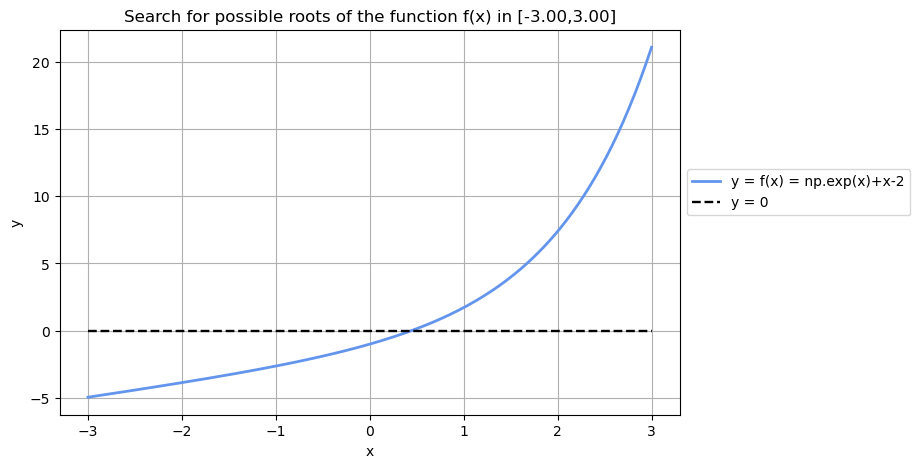

In [49]:
Graphfunc()

As we can see in the constructed plot, the true root of $f$ is indeed close to 0. Thus, an accepted initial estimation interval should be the [0,1] interval, as the function is continuous and changes sign within it. Other accepted intervals are the [-1,1] and [0,2], allowing us to examine the role of the interval length and the values of the initial bounds to the convergence of the method.

####  3.1.2 Approximating the root

To display the results of the Bisection method we use the **Convresults** function. To observe the convergence having [0,1] as initial interval, we follow the instructions below:

<u>Displaying the results of Bisection I<u> :

1. Type **1** to utilize the Bisection method (BM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **0** as the initial lower bound $x_l$   
4. Choose **1** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

In [30]:
Convresults()

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 1
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: 0
Give the initial upper bound of the approximation xu: 1
Give the number of the correct significant figures: 6



The Bisection method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %
-----------------------------------------------------------------------
i       x_r              x_l             x_u          e_a (%)
-----------------------------------------------------------------------
1   0.5000000000    0.0000000000    1.0000000000    NaN    (-)
2   0.2500000000    0.0000000000    0.5000000000    100.000000    (+)
3   0.3750000000    0.2500000000    0.5000000000    33.333333    (+)
4   0.4375000000    0.3750000000    0.5000000000    14.285714    (+)
5   0.4687500000    0.4375000000    0.5000000000    6.666667    (-)
6   0.4531250000    0.4375000000    0.4687500000    3.448276    (-)
7   0.4453125000    0.4375000000    0.4531250000    1.754386    (-)
8   0.4414062500    0.4375000000    0.4453125000    0.884956    (+)
9   0.4433593750    0.4414062500    0.4453125000    0.440529    (-)
10   0.4423828125    0.4414062500    0.4433593750   

Next, to observe the convergence having [-1,1] as initial interval, we follow the instructions below:

<u>Displaying the results of Bisection II<u> :

1. Type **1** to utilize the Bisection method (BM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **-1** as the initial lower bound $x_l$   
4. Choose **1** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

In [31]:
Convresults()

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 1
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: -1
Give the initial upper bound of the approximation xu: 1
Give the number of the correct significant figures: 6



The Bisection method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %
-----------------------------------------------------------------------
i       x_r              x_l             x_u          e_a (%)
-----------------------------------------------------------------------
1   0.0000000000    -1.0000000000    1.0000000000    NaN    (+)
2   0.5000000000    0.0000000000    1.0000000000    100.000000    (-)
3   0.2500000000    0.0000000000    0.5000000000    100.000000    (+)
4   0.3750000000    0.2500000000    0.5000000000    33.333333    (+)
5   0.4375000000    0.3750000000    0.5000000000    14.285714    (+)
6   0.4687500000    0.4375000000    0.5000000000    6.666667    (-)
7   0.4531250000    0.4375000000    0.4687500000    3.448276    (-)
8   0.4453125000    0.4375000000    0.4531250000    1.754386    (-)
9   0.4414062500    0.4375000000    0.4453125000    0.884956    (+)
10   0.4433593750    0.4414062500    0.4453125000

Finally, to observe the convergence having [0,2] as initial interval, we follow the instructions below:

<u>Displaying the results of Bisection III<u> :

1. Type **1** to utilize the Bisection method (BM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **0** as the initial lower bound $x_l$   
4. Choose **2** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

In [32]:
Convresults()

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 1
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: 0
Give the initial upper bound of the approximation xu: 2
Give the number of the correct significant figures: 6



The Bisection method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %
-----------------------------------------------------------------------
i       x_r              x_l             x_u          e_a (%)
-----------------------------------------------------------------------
1   1.0000000000    0.0000000000    2.0000000000    NaN    (-)
2   0.5000000000    0.0000000000    1.0000000000    100.000000    (-)
3   0.2500000000    0.0000000000    0.5000000000    100.000000    (+)
4   0.3750000000    0.2500000000    0.5000000000    33.333333    (+)
5   0.4375000000    0.3750000000    0.5000000000    14.285714    (+)
6   0.4687500000    0.4375000000    0.5000000000    6.666667    (-)
7   0.4531250000    0.4375000000    0.4687500000    3.448276    (-)
8   0.4453125000    0.4375000000    0.4531250000    1.754386    (-)
9   0.4414062500    0.4375000000    0.4453125000    0.884956    (+)
10   0.4433593750    0.4414062500    0.4453125000 

####  3.1.3 Plotting the approximate percent relative errors during the implementation

In order to confirm the results of the previous section (3.1.2), we plot the approximate percent relative errors evolution during the implententation of the Bisecton method, using the **Gconverrors** function. Having [0,1] as initial interval the evolution can be shown, by following the instructions below:

<u>Plotting the approximate errors evolution during Bisection implementation I<u> :

1. Type **1** to utilize the Bisection method (BM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **0** as the initial lower bound $x_l$   
4. Choose **1** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 1
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: 0
Give the initial upper bound of the approximation xu: 1
Give the number of the correct significant figures: 6


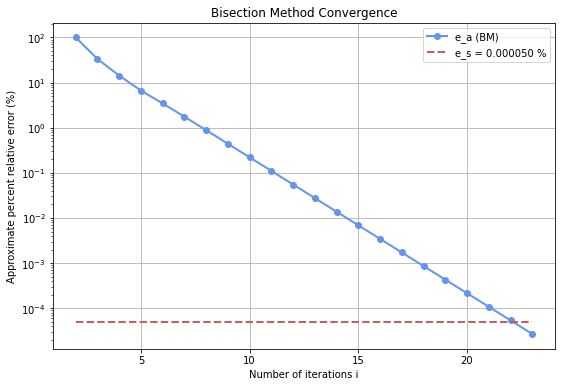

The Bisection method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %

The approximation has been completed after 23 iterations
The approximated root is equal to: 0.4428542852  (6 correct significant figures)


In [47]:
Gconverrors()

Having [-1,1] as initial interval the evolution can be shown, by following the instructions below:

<u>Plotting the approximate errors evolution during Bisection implementation II<u> :

1. Type **1** to utilize the Bisection method (BM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **-1** as the initial lower bound $x_l$   
4. Choose **1** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 1
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: -1
Give the initial upper bound of the approximation xu: 1
Give the number of the correct significant figures: 6


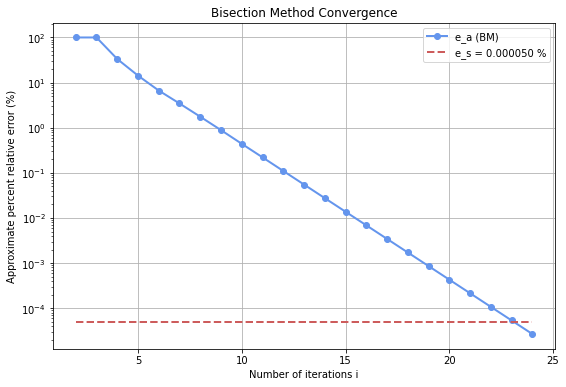

The Bisection method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %

The approximation has been completed after 24 iterations
The approximated root is equal to: 0.4428542852  (6 correct significant figures)


In [48]:
Gconverrors()

Having [0,2] as initial interval the evolution can be shown, by following the instructions below:

<u>Plotting the approximate errors evolution during Bisection implementation III<u> :

1. Type **1** to utilize the Bisection method (BM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **0** as the initial lower bound $x_l$   
4. Choose **2** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 1
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: 0
Give the initial upper bound of the approximation xu: 2
Give the number of the correct significant figures: 6


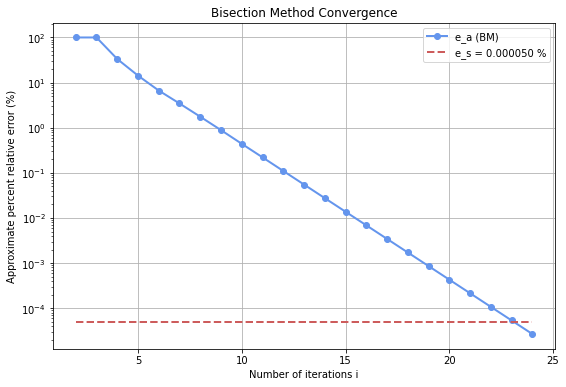

The Bisection method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %

The approximation has been completed after 24 iterations
The approximated root is equal to: 0.4428542852  (6 correct significant figures)


In [49]:
Gconverrors()

As it is shown above, the errors curve of the Bisection method is found below the Scarborough curve ($y=e_s$) at 23 or 24 iterations, respectively, terminating the iterative progress confirming the presented results of the method.

###  **3.2 Results for the Standard False Position Method**

####  3.2.1 Determinitation of the initial values

A second way to solve the requested equation: $e^x+x-2=0$, is by defining the same function $f(x)=e^x+x-2$ (as in Bisection), and find the roots of $f$, using the Standard False-Position method. This method, as an additional bracketing method (see sections 1.2.1 and 2.2.3), requires also two initial guesses $x_l$ and $x_u$ to be made. These guesses arise again from the plot of the $y=f(x)$ curve, using the **Graphfunc** function, according to the following instructions:

<u>Instructions for plotting *f*<u> :

1. Type **1** to choose the use of the graph for bracketing method (BM)
2. Type the formula of the function as: **np.exp(x)+x-2**
3. Choose **-3** as the lower limit of x-axis
4. Choose **3** as the upper limit of x-axis   

Choose the use of the graph (1=BM,2=FPI,3=FPI Derivative): 1
Type your one variable function formula: np.exp(x)+x-2
Give the lower limit of the x-axis of the plot: -3
Give the upper limit of the x-axis of the plot: 3


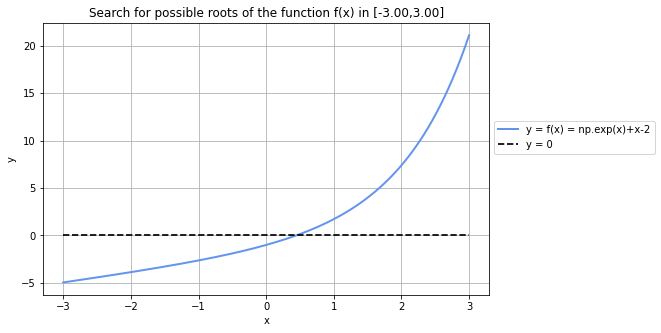

In [21]:
Graphfunc()

Of course this is the same plot as in the Bisection method, leading us to choose the same initial intervals [0,1], [-1,1] and [0,2], on account of the continuity and the change of sign of the function $f$ within them. Again, we will investigate how these intervals affect the convergence of the method. 

####  3.2.2 Approximating the root

Now we use the **Convresults** function to display the results of the Standard False-Position method. To observe the convergence having [0,1] as initial interval, we follow the instructions below:

<u>Displaying the results of Standard False-Position I<u> :

1. Type **2** to utilize the Standard False-Position method (SFPM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **0** as the initial lower bound $x_l$   
4. Choose **1** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

In [33]:
Convresults()

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 2
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: 0
Give the initial upper bound of the approximation xu: 1
Give the number of the correct significant figures: 6



The Standard False-Position method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %
-----------------------------------------------------------------------
i       x_r            x_l              x_u           e_a (%)
-----------------------------------------------------------------------
1   0.3678794412    0.0000000000    1.0000000000    NaN    (+)
2   0.4300563617    0.3678794412    1.0000000000    14.457854    (+)
3   0.4406680808    0.4300563617    1.0000000000    2.408098    (+)
4   0.4424808630    0.4406680808    1.0000000000    0.409686    (+)
5   0.4427905799    0.4424808630    1.0000000000    0.069947    (+)
6   0.4428434968    0.4427905799    1.0000000000    0.011949    (+)
7   0.4428525379    0.4428434968    1.0000000000    0.002042    (+)
8   0.4428540827    0.4428525379    1.0000000000    0.000349    (+)
9   0.4428543466    0.4428540827    1.0000000000    0.000060    (+)
10   0.4428543917    0.4428543466    1.00

Next, to observe the convergence having [-1,1] as initial interval, we follow the instructions below:

<u>Displaying the results of Standard False-Position II<u> :

1. Type **2** to utilize the Standard False-Position method (SFPM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **-1** as the initial lower bound $x_l$   
4. Choose **1** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

In [34]:
Convresults()

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 2
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: -1
Give the initial upper bound of the approximation xu: 1
Give the number of the correct significant figures: 6



The Standard False-Position method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %
-----------------------------------------------------------------------
i       x_r            x_l              x_u           e_a (%)
-----------------------------------------------------------------------
1   0.2100584381    -1.0000000000    1.0000000000    NaN    (+)
2   0.4032278724    0.2100584381    1.0000000000    47.905774    (+)
3   0.4360870622    0.4032278724    1.0000000000    7.535007    (+)
4   0.4416982426    0.4360870622    1.0000000000    1.270365    (+)
5   0.4426568664    0.4416982426    1.0000000000    0.216561    (+)
6   0.4428206510    0.4426568664    1.0000000000    0.036987    (+)
7   0.4428486346    0.4428206510    1.0000000000    0.006319    (+)
8   0.4428534158    0.4428486346    1.0000000000    0.001080    (+)
9   0.4428542327    0.4428534158    1.0000000000    0.000184    (+)
10   0.4428543722    0.4428542327    1.0

Finally, to observe the convergence having [0,2] as initial interval, we follow the instructions below:

<u>Displaying the results of Standard False-Position III<u> :

1. Type **2** to utilize the Standard False-Position method (SFPM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **0** as the initial lower bound $x_l$   
4. Choose **2** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

In [35]:
Convresults()

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 2
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: 0
Give the initial upper bound of the approximation xu: 2
Give the number of the correct significant figures: 6



The Standard False-Position method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %
-----------------------------------------------------------------------
i       x_r            x_l              x_u           e_a (%)
-----------------------------------------------------------------------
1   0.2384058440    0.0000000000    2.0000000000    NaN    (+)
2   0.3484564921    0.2384058440    2.0000000000    31.582321    (+)
3   0.3992924068    0.3484564921    2.0000000000    12.731500    (+)
4   0.4227593931    0.3992924068    2.0000000000    5.550908    (+)
5   0.4335865290    0.4227593931    2.0000000000    2.497111    (+)
6   0.4385804619    0.4335865290    2.0000000000    1.138658    (+)
7   0.4408835400    0.4385804619    2.0000000000    0.522378    (+)
8   0.4419455891    0.4408835400    2.0000000000    0.240312    (+)
9   0.4424353301    0.4419455891    2.0000000000    0.110692    (+)
10   0.4426611601    0.4424353301    2.0

####  3.2.3 Plotting the approximate percent relative errors during the implementation

In order to confirm the results of the previous section (3.2.2), we plot the approximate percent relative errors evolution during the implententation of the Standard False-Position method, using the **Gconverrors** function. Having [0,1] as initial interval the evolution can be shown, by following the instructions below:

<u>Plotting the approximate errors evolution during Standard False-Position implementation I<u> :

1. Type **2** to utilize the Standard False-Position method (SFPM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **0** as the initial lower bound $x_l$   
4. Choose **1** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 2
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: 0
Give the initial upper bound of the approximation xu: 1
Give the number of the correct significant figures: 6


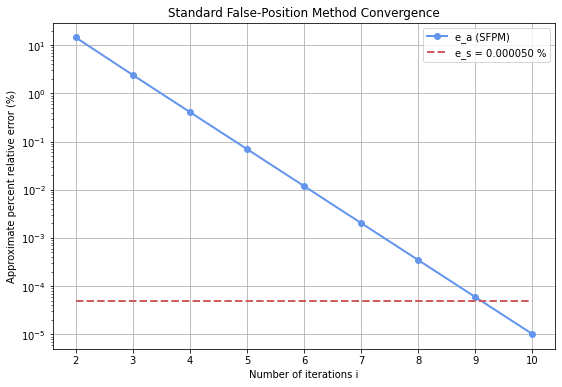

The Standard False-Position method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %

The approximation has been completed after 10 iterations
The approximated root is equal to: 0.4428543917  (6 correct significant figures)


In [52]:
Gconverrors()

Having [-1,1] as initial interval the evolution can be shown, by following the instructions below:

<u>Plotting the approximate errors evolution during Standard False-Position implementation II<u> :

1. Type **2** to utilize the Standard False-Position method (SFPM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **-1** as the initial lower bound $x_l$   
4. Choose **1** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 2
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: -1
Give the initial upper bound of the approximation xu: 1
Give the number of the correct significant figures: 6


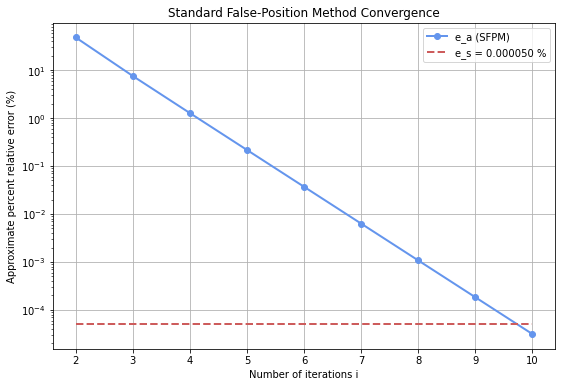

The Standard False-Position method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %

The approximation has been completed after 10 iterations
The approximated root is equal to: 0.4428543722  (6 correct significant figures)


In [53]:
Gconverrors()

Having [0,2] as initial interval the evolution can be shown, by following the instructions below:

<u>Plotting the approximate errors evolution during Standard False-Position implementation III<u> :

1. Type **2** to utilize the Standard False-Position method (SFPM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **0** as the initial lower bound $x_l$   
4. Choose **2** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 2
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: 0
Give the initial upper bound of the approximation xu: 2
Give the number of the correct significant figures: 6


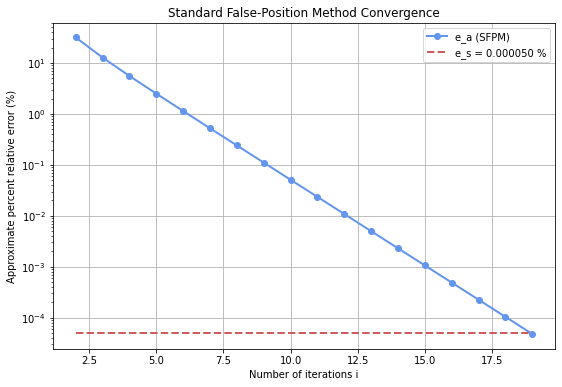

The Standard False-Position method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %

The approximation has been completed after 19 iterations
The approximated root is equal to: 0.4428542189  (6 correct significant figures)


In [54]:
Gconverrors()

As it is shown above, the errors curve of the Standard False-Position method is found below the Scarborough curve ($y=e_s$) at 10 or 19 iterations, respectively, terminating the iterative progress and confirming the presented results of the method.

###  **3.3 Results for the Modified False Position Method**

####  3.3.1 Determinitation of the initial values

For the Modified False-Position method, we will use the same initial intervals [0,1], [-1,1] and [0,2] of the Bisection and the Standard False-Position, as the function we are going to use is the same: $f(x)=e^x+x-2$ and because the only modifications that have been made relate to the sign checking phase of the product $f(x_r)*f(x_l)$ (see sections 1.2.2 and 2.2.4). Once again, we will investigate how the afformentioned intervals affect the convergence of the method.

####  3.3.2 Approximating the root

We use the **Convresults** function to display the results of the Modified False-Position method. To observe the convergence having [0,1] as initial interval, we follow the instructions below:

<u>Displaying the results of Modified False-Position I<u> :

1. Type **3** to utilize the Modified False-Position method (MFPM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **0** as the initial lower bound $x_l$   
4. Choose **1** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

In [36]:
Convresults()

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 3
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: 0
Give the initial upper bound of the approximation xu: 1
Give the number of the correct significant figures: 6



The Modified False-Position method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %
------------------------------------------------------------------------------------------------
i       x_r             x_l             x_u             f_l           f_u         e_a (%)
------------------------------------------------------------------------------------------------
1   0.3678794412    0.0000000000    1.0000000000    -1.00000000    1.71828183    NaN        (+)
2   0.4300563617    0.3678794412    1.0000000000    -0.18745270    1.71828183    14.457854    (+)
3   0.4508918659    0.4300563617    1.0000000000    -0.03259947    0.85914091    4.620954    (-)
4   0.4428230865    0.4300563617    0.4508918659    -0.03259947    0.02060340    1.822123    (+)
5   0.4428543244    0.4428230865    0.4508918659    -0.00008007    0.02060340    0.007054    (+)
6   0.4428544773    0.4428543244    0.4508918659    -0.00000020    0.01030170    0.000

Additionally, to observe the convergence having [-1,1] as initial interval, we follow the instructions below:

<u>Displaying the results of Modified False-Position II<u> :

1. Type **3** to utilize the Modified False-Position method (MFPM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **-1** as the initial lower bound $x_l$   
4. Choose **1** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

In [37]:
Convresults()

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 3
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: -1
Give the initial upper bound of the approximation xu: 1
Give the number of the correct significant figures: 6



The Modified False-Position method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %
------------------------------------------------------------------------------------------------
i       x_r             x_l             x_u             f_l           f_u         e_a (%)
------------------------------------------------------------------------------------------------
1   0.2100584381    -1.0000000000    1.0000000000    -2.63212056    1.71828183    NaN        (+)
2   0.4032278724    0.2100584381    1.0000000000    -0.55619141    1.71828183    47.905774    (+)
3   0.4655165422    0.4032278724    1.0000000000    -0.10012423    0.85914091    13.380549    (-)
4   0.4425811211    0.4032278724    0.4655165422    -0.10012423    0.05835329    5.182196    (+)
5   0.4428525142    0.4425811211    0.4655165422    -0.00069876    0.05835329    0.061283    (+)
6   0.4428562614    0.4428525142    0.4655165422    -0.00000482    0.02917664    0.0

Finally, to observe the convergence having [0,2] as initial interval, we follow the instructions below:

<u>Displaying the results of Modified False-Position III<u> :

1. Type **3** to utilize the Modified False-Position method (MFPM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **0** as the initial lower bound $x_l$   
4. Choose **2** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

In [38]:
Convresults()

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 3
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: 0
Give the initial upper bound of the approximation xu: 2
Give the number of the correct significant figures: 6



The Modified False-Position method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %
------------------------------------------------------------------------------------------------
i       x_r             x_l             x_u             f_l           f_u         e_a (%)
------------------------------------------------------------------------------------------------
1   0.2384058440    0.0000000000    2.0000000000    -1.00000000    7.38905610    NaN        (+)
2   0.3484564921    0.2384058440    2.0000000000    -0.49236996    7.38905610    31.582321    (+)
3   0.4470922296    0.3484564921    2.0000000000    -0.23466461    3.69452805    22.061609    (-)
4   0.4427329445    0.3484564921    0.4470922296    -0.23466461    0.01085075    0.984631    (+)
5   0.4428542443    0.4427329445    0.4470922296    -0.00031057    0.01085075    0.027390    (+)
6   0.4428545573    0.4428542443    0.4470922296    -0.00000040    0.00542537    0.00

####  3.3.3 Plotting the approximate percent relative errors during the implementation

In order to confirm the results of the previous section (3.3.2), we plot the approximate percent relative errors evolution during the implententation of the Modified False-Position method, using the **Gconverrors** function. Having [0,1] as initial interval the evolution can be shown, by following the instructions below:

<u>Plotting the approximate errors evolution during Modified False-Position implementation I<u> :

1. Type **3** to utilize the Modified False-Position method (MFPM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **0** as the initial lower bound $x_l$   
4. Choose **1** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 3
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: 0
Give the initial upper bound of the approximation xu: 1
Give the number of the correct significant figures: 6


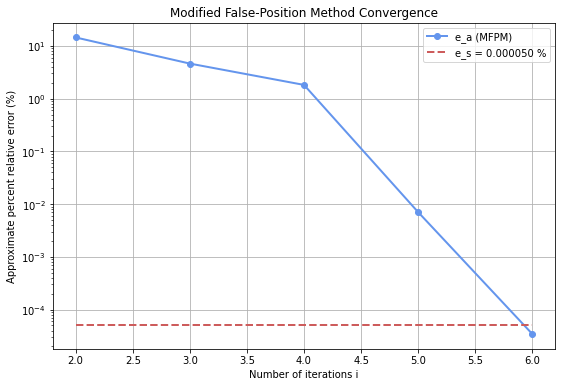

The Modified False-Position method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %

The approximation has been completed after 6 iterations
The approximated root is equal to: 0.4428544773  (6 correct significant figures)


In [55]:
Gconverrors()

Having [-1,1] as initial interval the evolution can be shown, by following the instructions below:

<u>Plotting the approximate errors evolution during Modified False-Position implementation II<u> :

1. Type **3** to utilize the Modified False-Position method (MFPM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **-1** as the initial lower bound $x_l$   
4. Choose **1** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 3
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: -1
Give the initial upper bound of the approximation xu: 1
Give the number of the correct significant figures: 6


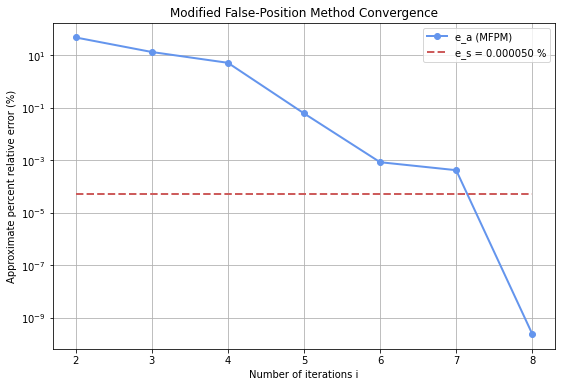

The Modified False-Position method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %

The true root is found equal to: 0.4428544010 after 8 iterations


In [56]:
Gconverrors()

Having [0,2] as initial interval the evolution can be shown, by following the instructions below:

<u>Plotting the approximate errors evolution during Modified False-Position implementation III<u> :

1. Type **3** to utilize the Modified False-Position method (MFPM)
2. Type the f(x) formula as: **np.exp(x)+x-2**
3. Choose **0** as the initial lower bound $x_l$   
4. Choose **2** as the initial upper bound $x_u$
5. Choose **6** to approximate the root with at least 6 correct significant figures    

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 3
Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: 0
Give the initial upper bound of the approximation xu: 2
Give the number of the correct significant figures: 6


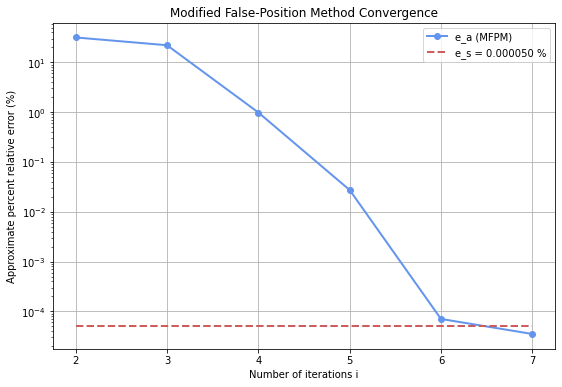

The Modified False-Position method was used for the function: f(x) = np.exp(x)+x-2
Tolerance according to Scarborough formula: e_s = 0.000050 %

The approximation has been completed after 7 iterations
The approximated root is equal to: 0.4428544010  (6 correct significant figures)


In [57]:
Gconverrors()

As it is shown above, the errors curve of the Modified False-Position method is found below the Scarborough curve ($y=e_s$) at 6, 8 and 7 iterations, respectively, terminating the iterative progress and confirming the presented results of the method.

###  **3.4 Results for the Fixed-Point Iteration**

####  3.4.1 Determinitation of the appropriate function and the initial point

To solve the equation $e^x+x-2=0$ using the Fixed-Point Iteration, we need to bring this equation in the form $x=g(x)$. The most obvious way, is to keep the '$x$' on the left side of the equation and bring all other terms to the right. This way, the equation $x=2-e^x$ is formed. We will now investigate if $g(x)=2-e^x$ is a suitable function for the method. An easy way to determine that, is by plotting the $y=g(x)=2-e^x$ curve and the curve of its first derivative, i.e $y=g^{'}(x)=-e^x$, according to the following instructions for the **Graphfunc** function:

<u>Instructions for plotting *g*<u> :

1. Type **2** to choose the use of the graph for Fixed-Point Iteration (FPI)
2. Type the formula of the function as: **2-np.exp(x)**
3. Choose **-1.5** as the lower limit of x-axis
4. Choose **1.5** as the upper limit of x-axis       

Choose the use of the graph (1=BM,2=FPI,3=FPI Derivative): 2
Type your one variable function formula: 2-np.exp(x)
Give the lower limit of the x-axis of the plot: -1.5
Give the upper limit of the x-axis of the plot: 1.5


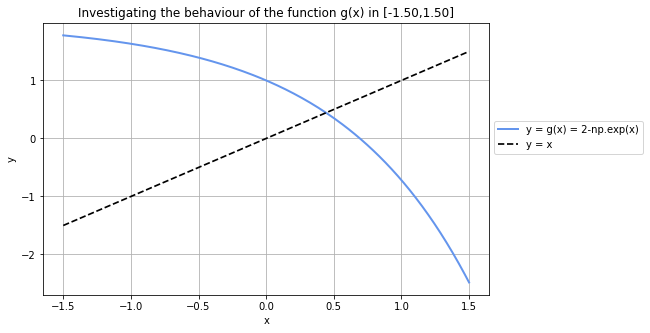

In [31]:
Graphfunc()

<u>Instructions for plotting *g'*<u> :

1. Type **3** to choose the use of the graph for the derivative of g to be used in Fixed-Point Iteration (FPI Derivative)
2. Type the formula of the function as: **-np.exp(x)**
3. Choose **-1.5** as the lower limit of x-axis
4. Choose **1.5** as the upper limit of x-axis       

Choose the use of the graph (1=BM,2=FPI,3=FPI Derivative): 3
Type your one variable function formula: -np.exp(x)
Give the lower limit of the x-axis of the plot: -1.5
Give the upper limit of the x-axis of the plot: 1.5


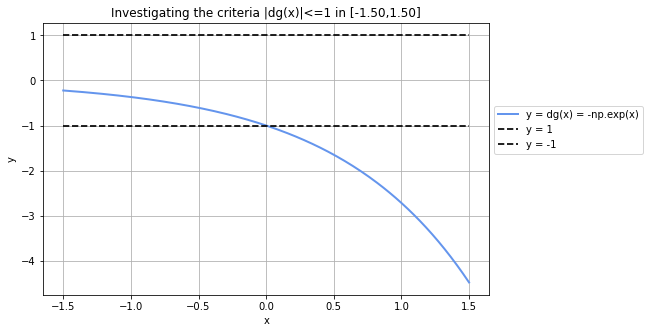

In [26]:
Graphfunc()

As shown in the previous graphs, the absolute slope of the $g$ function is bigger than 1 in the area near the intersection of the $y=g$ (that is close to x=0.5) curve with the $y=x$ curve, as the absolute values of $g^{'}$ grow bigger than 1 in this area, respectively. So, $g(x)=2-e^{x}$ is not suitable for the Fixed-Point iteration, as the convergence criteria $|g^{'}(x)|<1$ is not met (see 1.3 and 2.2.5).

Thus, we try again reforming the initial equation in a different way:
$$e^x+x-2=0 => e^x=2-x => x=ln(2-x)$$
Then, we investigate the behaviour of $g(x)=ln(2-x)$ by plotting its curve and the curve of its first derivative, i.e $y=g^{'}(x)=-\frac{1}{2-x}$, according to the following instructions:

<u>Instructions for plotting *g*<u> :

1. Type **2** to choose the use of the graph for Fixed-Point Iteration (FPI)
2. Type the formula of the function as: **np.log(2-x)**
3. Choose **-1.5** as the lower limit of x-axis
4. Choose **1.5** as the upper limit of x-axis      

Choose the use of the graph (1=BM,2=FPI,3=FPI Derivative): 2
Type your one variable function formula: np.log(2-x)
Give the lower limit of the x-axis of the plot: -1.5
Give the upper limit of the x-axis of the plot: 1.5


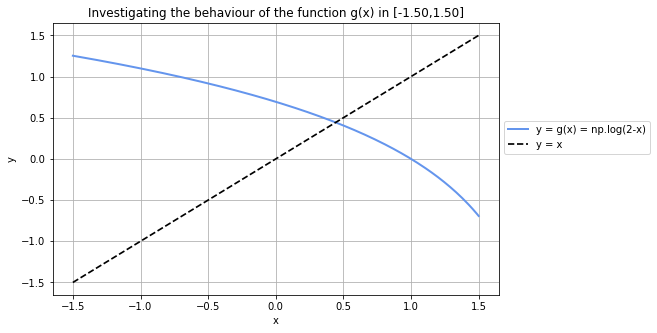

In [25]:
Graphfunc()

<u>Instructions for plotting *g'*<u> :

1. Type **3** to choose the use of the graph for the derivative of g to be used in Fixed-Point Iteration (FPI Derivative)
2. Type the formula of the function as: **-1/(2-x)**
3. Choose **-1.5** as the lower limit of x-axis
4. Choose **1.5** as the upper limit of x-axis   

Choose the use of the graph (1=BM,2=FPI,3=FPI Derivative): 3
Type your one variable function formula: -1/(2-x)
Give the lower limit of the x-axis of the plot: -1.5
Give the upper limit of the x-axis of the plot: 1.5


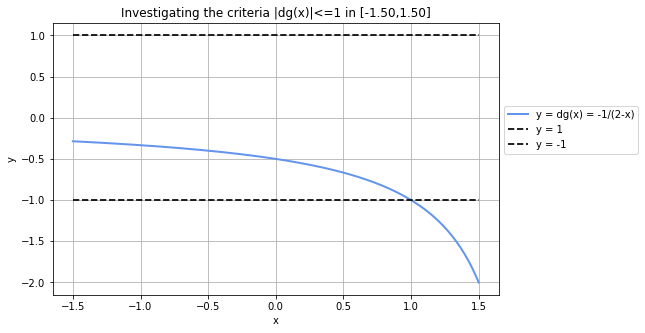

In [28]:
Graphfunc()

As we can see from the above diagrams, the criterion $|g^{'}(x)|<1$ is fulfilled at least in the region [-1,0.5] and the function $g(x)=ln(2-x)$ is suitable for the application of the Fixed-Point Iteration. Below, we will use three different initial points, -1, 0 and 0.5, examining their importance in the convergence of the method.

####  3.4.2 Approximating the root

We use the **Convresults** function to display the results of the Fixed-Point iteration. To observe the convergence having -1 as initial point, we follow the instructions below:

<u>Displaying the results of Fixed-Point Iteration I<u> :

1. Type **4** to utilize the Fixed-Point Iteration (FPI)
2. Type the g(x) formula as: **np.log(2-x)**
3. Choose **-1** as the initial point $x_o$   
4. Choose **6** to approximate the root with at least 6 correct significant figures    

In [39]:
Convresults()

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 4
Type the g(x) formula: np.log(2-x)
Give the initial guess xo: -1
Give the number of the correct significant figures: 6



The Fixed-Point Iteration was used for the function: g(x) = np.log(2-x)
Tolerance according to Scarborough formula: e_s = 0.000050 %
-------------------------------------------------
i       x_r             g_r          e_a (%)
-------------------------------------------------
0   -1.0000000000    1.0986122887    NaN
1   1.0986122887    -0.1038198017    191.023923
2   -0.1038198017    0.7437546456    1158.191473
3   0.7437546456    0.2281273948    113.958878
4   0.2281273948    0.5720369564    226.026011
5   0.5720369564    0.3562489838    60.120165
6   0.3562489838    0.4969808352    60.572235
7   0.4969808352    0.4074758617    28.317360
8   0.4074758617    0.4653202658    21.965712
9   0.4653202658    0.4283217170    12.431095
10   0.4283217170    0.4521440185    8.638028
11   0.4521440185    0.4368707357    5.268742
12   0.4368707357    0.4466897507    3.496065
13   0.4466897507    0.4403882984    2.198173
14   0.4403882984    0.4444368811    1.430886
15   0.4444368811    0.441837

Then, to observe the convergence having 0 as initial point, we follow the instructions below:

<u>Displaying the results of Fixed-Point Iteration II<u> :

1. Type **4** to utilize the Fixed-Point Iteration (FPI)
2. Type the g(x) formula as: **np.log(2-x)**
3. Choose **0** as the initial point $x_o$   
4. Choose **6** to approximate the root with at least 6 correct significant figures    

In [40]:
Convresults()

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 4
Type the g(x) formula: np.log(2-x)
Give the initial guess xo: 0
Give the number of the correct significant figures: 6



The Fixed-Point Iteration was used for the function: g(x) = np.log(2-x)
Tolerance according to Scarborough formula: e_s = 0.000050 %
-------------------------------------------------
i       x_r             g_r          e_a (%)
-------------------------------------------------
0   0.0000000000    0.6931471806    NaN
1   0.6931471806    0.2676218188    100.000000
2   0.2676218188    0.5494951357    159.002492
3   0.5494951357    0.3719116781    51.296781
4   0.3719116781    0.4874065179    47.748825
5   0.4874065179    0.4138257154    23.695793
6   0.4138257154    0.4613250066    17.780626
7   0.4613250066    0.4309216522    10.296275
8   0.4309216522    0.4504884074    7.055425
9   0.4504884074    0.4379397797    4.343454
10   0.4379397797    0.4460056040    2.865377
11   0.4460056040    0.4408286458    1.808458
12   0.4408286458    0.4441544969    1.174370
13   0.4441544969    0.4420191297    0.748805
14   0.4420191297    0.4433906690    0.483094
15   0.4433906690    0.4425099500    

Finally, to observe the convergence having 0.5 as initial point, we follow the instructions below:

<u>Displaying the results of Fixed-Point Iteration III<u> :

1. Type **4** to utilize the Fixed-Point Iteration (FPI)
2. Type the g(x) formula as: **np.log(2-x)**
3. Choose **0.5** as the initial point $x_o$   
4. Choose **6** to approximate the root with at least 6 correct significant figures    

In [41]:
Convresults()

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 4
Type the g(x) formula: np.log(2-x)
Give the initial guess xo: 0.5
Give the number of the correct significant figures: 6



The Fixed-Point Iteration was used for the function: g(x) = np.log(2-x)
Tolerance according to Scarborough formula: e_s = 0.000050 %
-------------------------------------------------
i       x_r             g_r          e_a (%)
-------------------------------------------------
0   0.5000000000    0.4054651081    NaN
1   0.4054651081    0.4665820899    23.315173
2   0.4665820899    0.4274991721    13.098870
3   0.4274991721    0.4526672361    9.142221
4   0.4526672361    0.4365326512    5.559948
5   0.4365326512    0.4469060143    3.696077
6   0.4469060143    0.4402490611    2.321151
7   0.4402490611    0.4445261539    1.512088
8   0.4445261539    0.4417802234    0.962169
9   0.4417802234    0.4435440008    0.621560
10   0.4435440008    0.4424114414    0.397656
11   0.4424114414    0.4431388295    0.255997
12   0.4431388295    0.4426717241    0.164145
13   0.4426717241    0.4429717093    0.105520
14   0.4429717093    0.4427790627    0.067721
15   0.4427790627    0.4429027822    0.04350

####  3.4.3 Plotting the approximate percent relative errors during the implementation

In order to confirm the results of the previous section (3.4.2), we plot the approximate percent relative errors evolution during the implententation of the Fixed-Point iteration, using the **Gconverrors** function. Having -1 as the initial point the evolution can be shown, by following the instructions below:

<u>Plotting the approximate errors evolution during Fixed-Point implementation I<u> :

1. Type **4** to utilize the Fixed-Point iteration (FPI)
2. Type the g(x) formula as: **np.log(2-x)**
3. Choose **-1** as the initial point $x_o$   
5. Choose **6** to approximate the root with at least 6 correct significant figures    

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 4
Type the g(x) formula: np.log(2-x)
Give the initial guess xo: -1
Give the number of the correct significant figures: 6


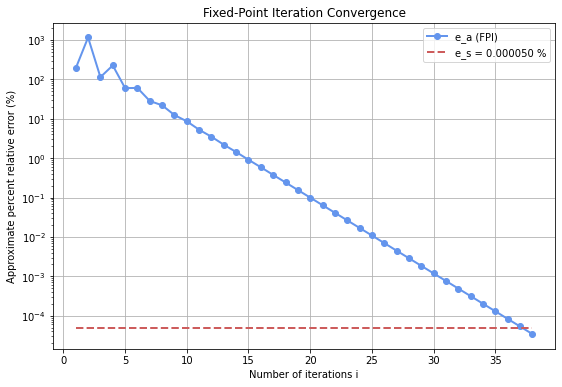

The Fixed-Point Iteration was used for the function: g(x) = np.log(2-x)
Tolerance according to Scarborough formula: e_s = 0.000050 %

The approximation has been completed after 38 iterations
The approximated root is equal to: 0.4428543413  (6 correct significant figures)


In [58]:
Gconverrors()

Having 0 as the initial point the evolution can be shown, by following the instructions below:

<u>Plotting the approximate errors evolution during Fixed-Point implementation II<u> :

1. Type **4** to utilize the Fixed-Point iteration (FPI)
2. Type the g(x) formula as: **np.log(2-x)**
3. Choose **0** as the initial point $x_o$   
5. Choose **6** to approximate the root with at least 6 correct significant figures    

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 4
Type the g(x) formula: np.log(2-x)
Give the initial guess xo: 0
Give the number of the correct significant figures: 6


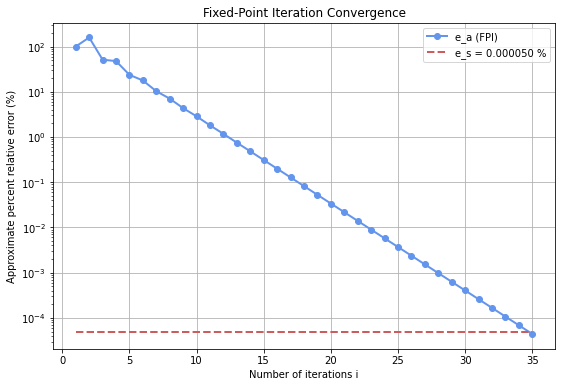

The Fixed-Point Iteration was used for the function: g(x) = np.log(2-x)
Tolerance according to Scarborough formula: e_s = 0.000050 %

The approximation has been completed after 35 iterations
The approximated root is equal to: 0.4428544774  (6 correct significant figures)


In [59]:
Gconverrors()

Having 0.5 as the initial point the evolution can be shown, by following the instructions below:

<u>Plotting the approximate errors evolution during Fixed-Point implementation III<u> :

1. Type **4** to utilize the Fixed-Point iteration (FPI)
2. Type the g(x) formula as: **np.log(2-x)**
3. Choose **0.5** as the initial point $x_o$   
5. Choose **6** to approximate the root with at least 6 correct significant figures    

Choose the approximation method by typing the appropriate number(1=BM,2=SFPM,3=MFPM,4=FPI): 4
Type the g(x) formula: np.log(2-x)
Give the initial guess xo: 0.5
Give the number of the correct significant figures: 6


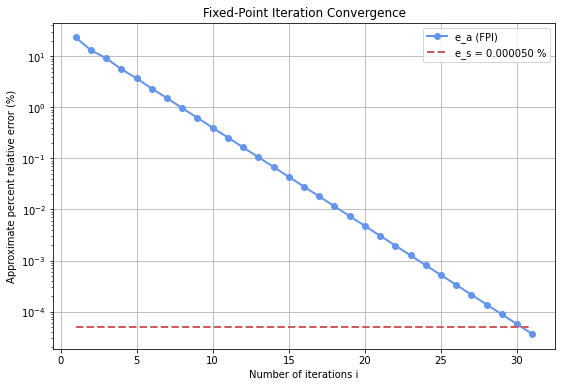

The Fixed-Point Iteration was used for the function: g(x) = np.log(2-x)
Tolerance according to Scarborough formula: e_s = 0.000050 %

The approximation has been completed after 31 iterations
The approximated root is equal to: 0.4428543379  (6 correct significant figures)


In [60]:
Gconverrors()

As it is shown above, the errors curve of the Fixed-POint iteration is found below the Scarborough curve ($y=e_s$) at 38, 35 and 31 iterations, respectively, terminating the iterative progress and confirming the presented results of the method.

###  **3.5 Comparing the methods**

In this section we compare the four numerical techniques that have been used in terms of speed of convergence, number of iterations used and ease of implementation. All methods result in the value **0.442854** as an approximation of the real root with 6 correctly significant figures. In addition according to the above, the Modified False-Position method is the fastest one, approximating the true root, by using **6 to 8** repetitions. Second in line, comes the Standard False-Position method using **10 or 19** to approximate the root. In the third place, we have the Bisection method, which approximates the root, using **23 or 24** iterations. Last but not least, the Fixed-Point iteration approximates the root using **31, 35 and 38** iterations, respectively. Of course, this numbers refer to the request of 6 correct significant figures.

We can confirm the above speed order of the methods by constructing a common graph of their approximate errors. This is possible by using the function **Compall** (see section 2.4.2). The best convergence is obtained for initial interval [0,1] for the three bracketing methods and initial point 0.5 for the Fixed-Point iteration, as shown below:

Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: 0
Give the initial upper bound of the approximation xu: 1
Type the g(x) formula: np.log(2-x)
Give the initial guess xo: 0.5
Give the number of the correct significant figures: 6


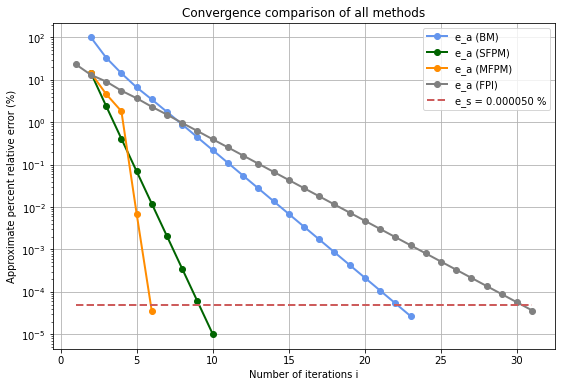

Tolerance according to Scarborough formula: e_s = 0.000050 %

Bisection Method:
The approximation has been completed after 23 iterations
The approximated root is equal to: 0.4428542852  (6 correct significant figures)

Standard False-Position Method:
The approximation has been completed after 10 iterations
The approximated root is equal to: 0.4428543917  (6 correct significant figures)

Modified False-Position Method:
The approximation has been completed after 6 iterations
The approximated root is equal to: 0.4428544773  (6 correct significant figures)

Fixed-Point Iteration:
The approximation has been completed after 31 iterations
The approximated root is equal to: 0.4428543379  (6 correct significant figures)


In [40]:
Compall()

On the opposite side, the worst convergence results for initial interval [0,2] for the three bracketing methods and initial point -1 for the Fixed-Point iteration, as shown below:

Type the f(x) formula: np.exp(x)+x-2
Give the initial lower bound of the approximation xl: 0
Give the initial upper bound of the approximation xu: 2
Type the g(x) formula: np.log(2-x)
Give the initial guess xo: -1
Give the number of the correct significant figures: 6


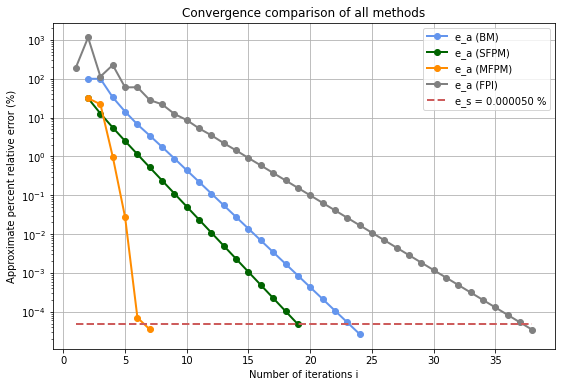

Tolerance according to Scarborough formula: e_s = 0.000050 %

Bisection Method:
The approximation has been completed after 24 iterations
The approximated root is equal to: 0.4428542852  (6 correct significant figures)

Standard False-Position Method:
The approximation has been completed after 19 iterations
The approximated root is equal to: 0.4428542189  (6 correct significant figures)

Modified False-Position Method:
The approximation has been completed after 7 iterations
The approximated root is equal to: 0.4428544010  (6 correct significant figures)

Fixed-Point Iteration:
The approximation has been completed after 38 iterations
The approximated root is equal to: 0.4428543413  (6 correct significant figures)


In [41]:
Compall()

When it comes to the ease of the implementation, the Bisection method is the fundamental bracketing method. The selection of the suitable function is relatively quickIts ανδ its implementation its quite simple, as it consists of an iterative process, executed by the *while* command, the calculation of the new root approximation, using the midpoiont formula and a control flow 'tree' inside the *while loop*, for the check phase of the product $f(x_r)*f(x_l)$ sign. The convergence criteria of the method are applied as conditions of the *while loop*. 

The Standard False-Position method is nothing but a merely improvement of the Bisection method. This improvement can be identified in the calculation formula of the new approximation, as the midpoint formula ($x_r=\frac{x_l+x_u}{2}$) is replaced by the linear interpolation formula ($x_r=x_u-\frac{f(x_u)(x_l-x_u)}{f(x_l)-f(x_u)}$). With this change, the behaviour of the selected function $f$ in the area close to the true root, is also taken into account. Other than that, the general structure of bracketing remains the same.  

The Modified False-Position method, offers a further improvement in bracketing by detecting the stagnant bounds of the Standard method. In this point, we need to mention that the 'stagnant bound problem' is a flaw of the Standard only. The Bisection method showed no stuck boundaries, at least this was the case in our problem. The prevention of stuck boundaries, comes with an addition in the control flow 'tree' that checks the consecutive times the product $f(x_r)*f(x_l)$ is found positive or negative and makes the appropriate changes, by dividing in half the function $f$ value at the upper or the lower bound, respectively. In our problem the upper bound is stagnant so the first case is applied. So, this far, nothing diffcult in terms of implemntation comes up. 

Finally, the Fixed-Point Iteration offers a much more simple implementation, as no check of the sign is included. However, the tricky part comes with the determination of the suitable function $g$. We saw that the most obvious choice is not always the best one. Of course, once we find a suitable fucntion that fulfills the convergence criterion $|g^{'}(x)|<1$, we can experiment and improve our choice, by decreasing the absolute value of the slope of our $g$ function, to be assured the criterion is met and accelerate our code.

###  **3.6 Conclusions**

It's time to make the conclusions of our attempt. According to the results of the **Bisection** method (see section 3.1.2), we can see that the true root is approximated, with 6 correct significant figures, by the value **0.442854**. This value is found after 23 or 24 iterations. The 23 iterations refer to the [0,1] initial interval, while the 24 iterations refer to the [-1,1] and [0,2] initial intervals, respectively. Thus, we can say that doubling the length of the initial interval does not play a very important role in convergence, since it only adds one more iteration to the whole process. What certainly does not matter is the behaviour of the function in the convergence region, as the same number of iterations is used for the two intervals [-1,1] and [0,2]. 

On the contrary, the behaviour of the function plays a role in the **Standard False-Position** method. The reults of this method (see section 3.2.2), showed us that when the stagnant bound remains unchanged the number of the iterations performed remains also unchanged. In our case the upper bound was stagnant. So, when its value remained the same at the change from the initial interval [0,1] to the initial interval [-1,1], the same number of iterations (10) was performed. The number of iterations was, however, increased from 10 to 19 when the initial upper bound 2 was used instead of the upper bound 1, leading to slower convergence. It is to our profit then to choose the stagnant bound to be as close as possible to the true root of the equation. Speaking of which, the same value **0.442854** (with 6 correct significant figures) of the approximated root is found.

Furthermore, the **Modified False-Position** method, takes into consdideration both the behaviour of the function in the convergence area and the possible existence of stagnant bound. It is therefore appropriate, to compare its results (see section 3.3.2) to those of the Standard method. In the [0,1] interval case, the code is accelerated by 4 iterations, as 6 iterations of the Modified method are executed, instead of 10 of the Standard one. The accelration point is located at the 3rd iteration. This can be easily confirmed by the half value of $f_u$ that was used at this iteration. It can also be confirmed by the approximate errors plot (see section 3.3.3) where the slope of the graph becomes steeper. In the [-1,1] case, the code is accelerated by 2 iterations, as 8 iterations of the Modified method are executed, instead of 10 of the Standard one. Finally in the [0,2] case, is the most remarkable one, as the code is accelerated by 12 iterations, using 7 iterations for the Modified method, instead of 19 for the Standard method, showing the much improved convergence of the Modified method. Once again of course, our root approximation with 6 correct significant figures is found equal to **0.442854**.

Coming to an end, in all of three cases of initial points (-1, 0, and 0,5) the **Fixed-Point Iteration** comes up with the same result **0.442854** for the approximation of the root with 6 correct significant figures. We can also, see that the method converges faster as the initial guess is being made closer to the true root. However, over 30 iterations are required in all cases, making this method the slowest one. As we mentioned before, this can improved by changing the selected function $g$ and find a more suitable one, that leads to faster convergence. 